## 03 Embedding Benchmark

This notebook benchmarks lexical and embedding-based similarity methods for curriculum overlap detection on the labeled curriculum-overlap dataset prepared in Notebook 01 and Notebook 02.

### Main goal

The purpose of Notebook 03 is to evaluate **score quality** and **representation quality**, not final threshold decisions.

It answers:

> Which embedding model, text representation, and similarity metric combination produces similarity scores that best separate meaningful overlap pairs from non-overlap pairs?

### What this notebook does

- loads the cleaned course dataset from Notebook 01
- loads the fully labeled pair dataset from Notebook 02
- validates the strong class imbalance explicitly
- creates a fixed **course-level** dev/test split
- discards mixed pairs where one course is in dev and the other is in test
- benchmarks:
  - TF-IDF baseline
  - BM25 baseline
  - OpenAI `text-embedding-3-large`
  - `intfloat/multilingual-e5-base`
  - `intfloat/multilingual-e5-large`
  - `intfloat/multilingual-e5-large-instruct`
  - `BAAI/bge-m3`
- compares text variants:
  - `embedding_text_main`
  - `embedding_text_enriched`
  - `embedding_text_full`
- compares similarity metrics where appropriate:
  - cosine similarity
  - dot product
  - native BM25 score for the BM25 baseline
- evaluates ranking quality primarily on the **development split**
- saves benchmark tables and figures for Notebook 04

### What this notebook does not do

- it does not choose the final production threshold
- it does not finalize the classifier decision rule
- it does not rebalance the naturally imbalanced dataset
- it does not treat accuracy as the main benchmark metric

### Important methodological note

The labeled dataset is strongly imbalanced because meaningful curriculum overlap is rare in the real course set.

For that reason, **raw accuracy is not a meaningful headline metric** in this notebook.

The primary focus is on:

- Average Precision / PR-AUC
- ROC-AUC as a secondary ranking metric
- Spearman correlation as an additional ranking-oriented diagnostic
- score separation between positives and negatives
- qualitative inspection of top-ranked pairs and hard false positives

### Split design

This notebook uses a **course-level split** rather than a pair-level split.

That means:
- a course is assigned either to dev or to test
- a pair is assigned to dev only if both courses are in dev
- a pair is assigned to test only if both courses are in test
- mixed pairs are excluded from benchmark evaluation

This is more conservative than a pair-level split and provides a more honest held-out evaluation.

In [1]:
# Cell 01 - Import libraries and define project paths

from pathlib import Path
import os
import time
import random
import warnings
import gc
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from dotenv import load_dotenv

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import normalize

from scipy.stats import spearmanr
from sentence_transformers import SentenceTransformer
from openai import OpenAI

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "benchmark"
TABLES_DIR = REPORTS_DIR / "tables" / "benchmark"
EMBEDDINGS_DIR = DATA_DIR / "embeddings"
BENCHMARK_PAIRS_DIR = DATA_DIR / "benchmark_pairs"
SPLITS_DIR = DATA_DIR / "splits"

COURSES_CSV_PATH = DATA_DIR / "courses_clean.csv"
PAIRS_CSV_PATH = DATA_DIR / "gold_pairs_review_labeled.csv"
ENV_PATH = PROJECT_ROOT / ".env"

COURSE_SPLIT_CSV_PATH = SPLITS_DIR / "course_dev_test_split.csv"
PAIR_SPLIT_CSV_PATH = SPLITS_DIR / "pair_dev_test_split_course_level.csv"

PAIR_SCORES_CSV_PATH = BENCHMARK_PAIRS_DIR / "pair_similarity_scores_long.csv"
PAIR_SCORES_PARQUET_PATH = BENCHMARK_PAIRS_DIR / "pair_similarity_scores_long.parquet"
EMBEDDING_INVENTORY_CSV_PATH = EMBEDDINGS_DIR / "embedding_inventory.csv"

DEV_SUMMARY_CSV_PATH = TABLES_DIR / "benchmark_summary_dev.csv"
LEADERBOARD_CSV_PATH = TABLES_DIR / "benchmark_leaderboard_dev.csv"
TOP_PAIRS_CSV_PATH = TABLES_DIR / "top_ranked_dev_pairs_by_config.csv"
HARD_FALSE_POSITIVES_CSV_PATH = TABLES_DIR / "hard_false_positives_dev_top5_by_config.csv"
SHORTLIST_CSV_PATH = TABLES_DIR / "shortlist_for_notebook_04.csv"

for path in [FIGURES_DIR, TABLES_DIR, EMBEDDINGS_DIR, BENCHMARK_PAIRS_DIR, SPLITS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
TEST_COURSE_FRACTION = 0.30
COURSE_SPLIT_SEARCH_TRIALS = 20000

TARGET_MIN_TEST_POSITIVES = 6
FALLBACK_MIN_TEST_POSITIVES = 5
MIN_DEV_POSITIVES = 20

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Project root:", PROJECT_ROOT)
print("Courses CSV:", COURSES_CSV_PATH)
print("Pairs CSV:", PAIRS_CSV_PATH)
print("Environment file:", ENV_PATH)
print("Figures dir:", FIGURES_DIR)
print("Tables dir:", TABLES_DIR)
print("Embeddings dir:", EMBEDDINGS_DIR)
print("Benchmark pairs dir:", BENCHMARK_PAIRS_DIR)
print("Splits dir:", SPLITS_DIR)
print("CUDA available:", torch.cuda.is_available())

Project root: C:\Users\user\Downloads\curriculum-overlap-poc
Courses CSV: C:\Users\user\Downloads\curriculum-overlap-poc\data\courses_clean.csv
Pairs CSV: C:\Users\user\Downloads\curriculum-overlap-poc\data\gold_pairs_review_labeled.csv
Environment file: C:\Users\user\Downloads\curriculum-overlap-poc\.env
Figures dir: C:\Users\user\Downloads\curriculum-overlap-poc\reports\figures\benchmark
Tables dir: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark
Embeddings dir: C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings
Benchmark pairs dir: C:\Users\user\Downloads\curriculum-overlap-poc\data\benchmark_pairs
Splits dir: C:\Users\user\Downloads\curriculum-overlap-poc\data\splits
CUDA available: False


### Environment setup

This notebook supports both:

- local open-source embedding models
- OpenAI embedding API evaluation

Expected `.env` file location:

`curriculum-overlap-poc/.env`

Expected variable:

- `OPENAI_API_KEY`

In [2]:
# Cell 02 - Load environment variables and initialize OpenAI client if available

load_dotenv(ENV_PATH)

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "").strip()

openai_client = None
if OPENAI_API_KEY:
    openai_client = OpenAI(api_key=OPENAI_API_KEY)
    print("OpenAI API key loaded: Yes")
else:
    print("OpenAI API key loaded: No")

USE_OPENAI_MODEL = bool(OPENAI_API_KEY)
print("Use OpenAI benchmark:", USE_OPENAI_MODEL)

OpenAI API key loaded: Yes
Use OpenAI benchmark: True


### Load datasets

This notebook uses:

- `courses_clean.csv` from Notebook 01
- `gold_pairs_review_labeled.csv` from Notebook 02

Because the current corpus combines courses from two institutions, Notebook 03 treats `institution` as important reference metadata for auditing and split integrity. However, institution is still **not** used as embedding text.

In [3]:
# Cell 03 - Load datasets

if not COURSES_CSV_PATH.exists():
    raise FileNotFoundError(f"Courses CSV not found: {COURSES_CSV_PATH}")

if not PAIRS_CSV_PATH.exists():
    raise FileNotFoundError(f"Labeled pairs CSV not found: {PAIRS_CSV_PATH}")

courses_df = pd.read_csv(COURSES_CSV_PATH, encoding="utf-8", keep_default_na=False)
pairs_df = pd.read_csv(PAIRS_CSV_PATH, encoding="utf-8", keep_default_na=False)

print("courses_df shape:", courses_df.shape)
print("pairs_df shape:", pairs_df.shape)

print("\nCourse columns:")
print(courses_df.columns.tolist())

print("\nPair columns:")
print(pairs_df.columns.tolist())

print("\nOne transposed course row:")
display(courses_df.head(1).T)

print("\nOne transposed pair row:")
display(pairs_df.head(1).T)

courses_df shape: (50, 26)
pairs_df shape: (1225, 14)

Course columns:
['institution', 'degree_programme', 'course_name', 'course_unit_code', 'credits', 'teaching_language_text', 'responsible_person_text', 'objective_text', 'competences_knowledge_text', 'competences_practice_text', 'competences_applying_technology_text', 'competences_multidisciplinary_text', 'competences_communication_text', 'competences_investigations_text', 'learning_outcomes_text', 'content_text', 'prerequisites_text', 'assessment_grading_scale', 'assessment_text', 'course_name_normalized', 'prerequisites_text_normalized', 'embedding_text_main', 'embedding_text_enriched', 'embedding_text_full', 'review_text_compact', 'review_text_full']

Pair columns:
['pair_id', 'institution_1', 'degree_programme_1', 'course_unit_code_1', 'course_name_1', 'review_text_1', 'institution_2', 'degree_programme_2', 'course_unit_code_2', 'course_name_2', 'review_text_2', 'overlap_label', 'review_status', 'review_notes']

One transposed c

,0
institution,JAMK
degree_programme,Information and Communication Technology
course_name,Data Networks
course_unit_code,TT00CD70
credits,5
teaching_language_text,"Finnish, English"
responsible_person_text,Pasi Hyytiäinen
objective_text,You learn the structure and protocols of data networks used by computers and other end devices. You know the principles of planning a data network. You are ...
competences_knowledge_text,You know the main modeling methods of data networks. You have knowledge and understanding of data networks and their effects. You know the basic principles ...
competences_practice_text,You can apply data network skills to communication between devices.



One transposed pair row:


,0
pair_id,TE00CN56__TE00CS88
institution_1,Turku AMK
degree_programme_1,Information and Communication Technology
course_unit_code_1,TE00CN56
course_name_1,Internet Networks and Security
review_text_1,Institution: Turku AMK\nCourse code: TE00CN56\nCourse name: Internet Networks and Security\nObjective: After completing the course the student: can name the...
institution_2,Turku AMK
degree_programme_2,Information and Communication Technology
course_unit_code_2,TE00CS88
course_name_2,Introduction to Programming


In [4]:
# Cell 04 - Validate required columns

required_course_columns = [
    "institution",
    "degree_programme",
    "course_name",
    "course_unit_code",
    "embedding_text_main",
    "embedding_text_enriched",
    "embedding_text_full",
    "review_text_full",
]

required_pair_columns = [
    "pair_id",
    "institution_1",
    "course_unit_code_1",
    "course_name_1",
    "review_text_1",
    "institution_2",
    "course_unit_code_2",
    "course_name_2",
    "review_text_2",
    "overlap_label",
    "review_status",
    "review_notes",
]

missing_course_columns = [col for col in required_course_columns if col not in courses_df.columns]
missing_pair_columns = [col for col in required_pair_columns if col not in pairs_df.columns]

if missing_course_columns:
    raise ValueError(f"Missing required course columns: {missing_course_columns}")

if missing_pair_columns:
    raise ValueError(f"Missing required pair columns: {missing_pair_columns}")

if courses_df["course_unit_code"].duplicated().any():
    duplicate_codes = courses_df.loc[
        courses_df["course_unit_code"].duplicated(keep=False),
        ["institution", "course_unit_code", "course_name"]
    ].sort_values(["course_unit_code", "institution"])
    raise ValueError(
        "Duplicate course_unit_code values found in courses_df.\n"
        f"{duplicate_codes}"
    )

if pairs_df["pair_id"].duplicated().any():
    raise ValueError("Duplicate pair_id values found in pairs_df.")

print("All required columns are present.")
print("Unique course codes:", courses_df["course_unit_code"].nunique())
print("Unique course names:", courses_df["course_name"].nunique())
print("Unique institutions:", courses_df["institution"].nunique())

print("\nInstitution distribution in courses_df:")
display(courses_df["institution"].value_counts())

All required columns are present.
Unique course codes: 50
Unique course names: 47
Unique institutions: 2

Institution distribution in courses_df:


institution
JAMK         41
Turku AMK     9
Name: count, dtype: int64

In [5]:
# Cell 05 - Normalize labels and review status

def normalize_overlap_label(value):
    text = str(value).strip().lower()
    if text in {"1", "true", "yes", "overlap"}:
        return 1
    if text in {"0", "false", "no", "none", "no overlap"}:
        return 0
    return np.nan

pairs_df["overlap_label_binary"] = pairs_df["overlap_label"].apply(normalize_overlap_label)
pairs_df["review_status_normalized"] = pairs_df["review_status"].astype(str).str.strip().str.lower()

invalid_label_count = int(pairs_df["overlap_label_binary"].isna().sum())
if invalid_label_count > 0:
    invalid_rows = pairs_df.loc[
        pairs_df["overlap_label_binary"].isna(),
        ["pair_id", "overlap_label", "review_status"]
    ].head(20)
    raise ValueError(
        f"Found {invalid_label_count} invalid overlap_label values.\n"
        f"Example rows:\n{invalid_rows}"
    )

reviewed_count = int((pairs_df["review_status_normalized"] == "reviewed").sum())
unreviewed_count = int((pairs_df["review_status_normalized"] != "reviewed").sum())

print("Rows with valid binary label:", len(pairs_df))
print("Reviewed rows:", reviewed_count)
print("Unreviewed rows:", unreviewed_count)
print("Positive labels:", int(pairs_df["overlap_label_binary"].sum()))
print("Negative labels:", int((pairs_df["overlap_label_binary"] == 0).sum()))

if unreviewed_count > 0:
    unreviewed_examples = pairs_df.loc[
        pairs_df["review_status_normalized"] != "reviewed",
        ["pair_id", "review_status"]
    ].head(20)
    raise ValueError(
        "Notebook 03 expects a fully reviewed label file. "
        "Some rows do not have review_status='reviewed'.\n"
        f"Example rows:\n{unreviewed_examples}"
    )

display(pairs_df["overlap_label_binary"].value_counts().sort_index())

Rows with valid binary label: 1225
Reviewed rows: 1225
Unreviewed rows: 0
Positive labels: 33
Negative labels: 1192


overlap_label_binary
0    1192
1      33
Name: count, dtype: int64

In [6]:
# Cell 06 - Class imbalance audit

total_pairs = len(pairs_df)
positive_pairs = int(pairs_df["overlap_label_binary"].sum())
negative_pairs = int((pairs_df["overlap_label_binary"] == 0).sum())
positive_rate = positive_pairs / total_pairs

pairs_df["institution_pair_type"] = np.where(
    pairs_df["institution_1"] == pairs_df["institution_2"],
    "same_institution",
    "cross_institution"
)

imbalance_summary = pd.Series({
    "total_pairs": total_pairs,
    "positive_pairs": positive_pairs,
    "negative_pairs": negative_pairs,
    "positive_rate": round(positive_rate, 6),
    "negative_to_positive_ratio": round(negative_pairs / positive_pairs, 2) if positive_pairs > 0 else np.nan,
})

display(imbalance_summary)

institution_pair_audit_df = (
    pairs_df.groupby("institution_pair_type")["overlap_label_binary"]
    .agg(
        pair_count="count",
        positive_count="sum",
        positive_rate="mean"
    )
    .reset_index()
)

institution_pair_audit_df["positive_count"] = institution_pair_audit_df["positive_count"].astype(int)
institution_pair_audit_df["positive_rate"] = institution_pair_audit_df["positive_rate"].round(6)

print("\nInstitution-pair audit:")
display(institution_pair_audit_df)

print("Interpretation:")
print(
    "This is a strongly imbalanced ranking problem. "
    "Average Precision and PR-based interpretation are more informative than raw accuracy. "
    "The two-institution corpus was used to make the overlap benchmark more usable, "
    "but overlap remains intentionally rare and should be evaluated honestly."
)

total_pairs                   1225.000000
positive_pairs                  33.000000
negative_pairs                1192.000000
positive_rate                    0.026939
negative_to_positive_ratio      36.120000
dtype: float64


Institution-pair audit:


,institution_pair_type,pair_count,positive_count,positive_rate
0,cross_institution,369,13,0.035230
1,same_institution,856,20,0.023364


Interpretation:
This is a strongly imbalanced ranking problem. Average Precision and PR-based interpretation are more informative than raw accuracy. The two-institution corpus was used to make the overlap benchmark more usable, but overlap remains intentionally rare and should be evaluated honestly.


### Create a fixed course-level dev/test split

This notebook uses a **course-level split** rather than splitting pairs directly.

A pair is assigned:
- `dev` if both courses are in the dev course set
- `test` if both courses are in the test course set
- `mixed_discard` if one course is in dev and the other is in test

Mixed pairs are excluded from benchmark evaluation.

#### Important note about split construction

Because the labeled dataset is small and positive overlap pairs are rare, the notebook uses a constrained deterministic search to find a **course-level split that preserves a minimally usable number of positive pairs in both dev and test**.

This improves practical usability for Notebook 03 and Notebook 04, but it is not the same as a completely arbitrary single split. That should be acknowledged as a methodological limitation in the thesis.

In [7]:
# Cell 07 - Search for a course-level split that preserves usable positive pairs

all_course_codes = sorted(courses_df["course_unit_code"].tolist())
n_courses = len(all_course_codes)
n_test_courses = int(round(n_courses * TEST_COURSE_FRACTION))

positive_pairs_df = pairs_df[pairs_df["overlap_label_binary"] == 1].copy()

best_result = None

for trial in range(COURSE_SPLIT_SEARCH_TRIALS):
    rng = random.Random(RANDOM_SEED + trial)
    test_courses = set(rng.sample(all_course_codes, n_test_courses))
    dev_courses = set(all_course_codes) - test_courses

    pair_split_labels = []
    for _, row in pairs_df.iterrows():
        c1 = row["course_unit_code_1"]
        c2 = row["course_unit_code_2"]

        if c1 in dev_courses and c2 in dev_courses:
            pair_split_labels.append("dev")
        elif c1 in test_courses and c2 in test_courses:
            pair_split_labels.append("test")
        else:
            pair_split_labels.append("mixed_discard")

    temp_df = pairs_df[[
        "pair_id",
        "institution_1",
        "institution_2",
        "overlap_label_binary"
    ]].copy()
    temp_df["split"] = pair_split_labels
    temp_df["institution_pair_type"] = np.where(
        temp_df["institution_1"] == temp_df["institution_2"],
        "same_institution",
        "cross_institution"
    )

    dev_pos = int(temp_df.loc[
        (temp_df["split"] == "dev") & (temp_df["overlap_label_binary"] == 1)
    ].shape[0])

    test_pos = int(temp_df.loc[
        (temp_df["split"] == "test") & (temp_df["overlap_label_binary"] == 1)
    ].shape[0])

    dev_pairs = int((temp_df["split"] == "dev").sum())
    test_pairs = int((temp_df["split"] == "test").sum())
    usable_pairs = dev_pairs + test_pairs
    mixed_discard_pairs = int((temp_df["split"] == "mixed_discard").sum())
    kept_positives = dev_pos + test_pos

    dev_cross_inst_pos = int(temp_df.loc[
        (temp_df["split"] == "dev") &
        (temp_df["overlap_label_binary"] == 1) &
        (temp_df["institution_pair_type"] == "cross_institution")
    ].shape[0])

    test_cross_inst_pos = int(temp_df.loc[
        (temp_df["split"] == "test") &
        (temp_df["overlap_label_binary"] == 1) &
        (temp_df["institution_pair_type"] == "cross_institution")
    ].shape[0])

    feasible_target = (
        dev_pos >= MIN_DEV_POSITIVES
        and test_pos >= TARGET_MIN_TEST_POSITIVES
        and test_pairs > 0
    )

    feasible_fallback = (
        dev_pos >= MIN_DEV_POSITIVES
        and test_pos >= FALLBACK_MIN_TEST_POSITIVES
        and test_pairs > 0
    )

    candidate = {
        "trial": trial,
        "dev_courses": sorted(dev_courses),
        "test_courses": sorted(test_courses),
        "dev_pairs": dev_pairs,
        "test_pairs": test_pairs,
        "usable_pairs": usable_pairs,
        "mixed_discard_pairs": mixed_discard_pairs,
        "dev_positives": dev_pos,
        "test_positives": test_pos,
        "kept_positives": kept_positives,
        "discarded_positives": int(positive_pairs_df.shape[0] - kept_positives),
        "dev_cross_institution_positives": dev_cross_inst_pos,
        "test_cross_institution_positives": test_cross_inst_pos,
        "feasible_target": feasible_target,
        "feasible_fallback": feasible_fallback,
    }

    if best_result is None:
        best_result = candidate
    else:
        current_key = (
            candidate["feasible_target"],
            candidate["feasible_fallback"],
            candidate["kept_positives"],
            candidate["test_positives"],
            candidate["dev_positives"],
            candidate["usable_pairs"],
            candidate["test_cross_institution_positives"],
            candidate["dev_cross_institution_positives"],
            -abs(candidate["test_pairs"] - 105),
        )

        best_key = (
            best_result["feasible_target"],
            best_result["feasible_fallback"],
            best_result["kept_positives"],
            best_result["test_positives"],
            best_result["dev_positives"],
            best_result["usable_pairs"],
            best_result["test_cross_institution_positives"],
            best_result["dev_cross_institution_positives"],
            -abs(best_result["test_pairs"] - 105),
        )

        if current_key > best_key:
            best_result = candidate

if best_result is None:
    raise ValueError("Failed to construct a course-level split.")

if best_result["feasible_target"]:
    split_selection_status = (
        f"Target achieved: at least {TARGET_MIN_TEST_POSITIVES} test positives."
    )
elif best_result["feasible_fallback"]:
    split_selection_status = (
        f"Fallback used: target of {TARGET_MIN_TEST_POSITIVES} test positives not found, "
        f"but at least {FALLBACK_MIN_TEST_POSITIVES} test positives was achieved."
    )
else:
    raise ValueError(
        "No feasible course-level split found that satisfies the minimum positive-pair requirements."
    )

split_summary_series = pd.Series({
    "split_selection_status": split_selection_status,
    "feasible_target": best_result["feasible_target"],
    "feasible_fallback": best_result["feasible_fallback"],
    "dev_pairs": best_result["dev_pairs"],
    "test_pairs": best_result["test_pairs"],
    "usable_pairs": best_result["usable_pairs"],
    "mixed_discard_pairs": best_result["mixed_discard_pairs"],
    "dev_positives": best_result["dev_positives"],
    "test_positives": best_result["test_positives"],
    "kept_positives": best_result["kept_positives"],
    "discarded_positives": best_result["discarded_positives"],
    "dev_cross_institution_positives": best_result["dev_cross_institution_positives"],
    "test_cross_institution_positives": best_result["test_cross_institution_positives"],
})

print("Best course-level split found:")
display(split_summary_series)

print()
print("Interpretation:")
print(
    "This split was chosen to preserve a workable number of positives in both development and test. "
    "It is more defensible than a pair-level split, but it is still a constrained split search rather than a fully arbitrary single holdout."
)

Best course-level split found:


split_selection_status              Target achieved: at least 6 test positives.
feasible_target                                                            True
feasible_fallback                                                          True
dev_pairs                                                                   595
test_pairs                                                                  105
usable_pairs                                                                700
mixed_discard_pairs                                                         525
dev_positives                                                                22
test_positives                                                                8
kept_positives                                                               30
discarded_positives                                                           3
dev_cross_institution_positives                                               8
test_cross_institution_positives        


Interpretation:
This split was chosen to preserve a workable number of positives in both development and test. It is more defensible than a pair-level split, but it is still a constrained split search rather than a fully arbitrary single holdout.


In [8]:
# Cell 08 - Save course-level split and assign pair splits

course_split_df = pd.DataFrame({
    "course_unit_code": all_course_codes,
})
course_split_df["split"] = np.where(
    course_split_df["course_unit_code"].isin(best_result["test_courses"]),
    "test",
    "dev"
)

course_split_df = course_split_df.merge(
    courses_df[["course_unit_code", "institution", "course_name"]],
    on="course_unit_code",
    how="left"
)

course_split_df = course_split_df[[
    "course_unit_code",
    "course_name",
    "institution",
    "split",
]].sort_values(["split", "institution", "course_unit_code"]).reset_index(drop=True)

course_split_df.to_csv(COURSE_SPLIT_CSV_PATH, index=False, encoding="utf-8")

course_split_map = dict(zip(course_split_df["course_unit_code"], course_split_df["split"]))

pairs_df["course_split_1"] = pairs_df["course_unit_code_1"].map(course_split_map)
pairs_df["course_split_2"] = pairs_df["course_unit_code_2"].map(course_split_map)

def assign_pair_split(row):
    if row["course_split_1"] == "dev" and row["course_split_2"] == "dev":
        return "dev"
    if row["course_split_1"] == "test" and row["course_split_2"] == "test":
        return "test"
    return "mixed_discard"

pairs_df["split"] = pairs_df.apply(assign_pair_split, axis=1)

pairs_df[[
    "pair_id",
    "course_unit_code_1",
    "course_unit_code_2",
    "split",
]].to_csv(PAIR_SPLIT_CSV_PATH, index=False, encoding="utf-8")

print("Saved course split to:", COURSE_SPLIT_CSV_PATH)
print("Saved pair split to:", PAIR_SPLIT_CSV_PATH)

print("\nCourse split counts:")
display(course_split_df["split"].value_counts())

print("\nCourse split by institution:")
display(pd.crosstab(course_split_df["institution"], course_split_df["split"]))

print("\nPair split counts and positive counts:")
display(
    pairs_df.groupby("split")["overlap_label_binary"]
    .agg(["count", "sum"])
    .rename(columns={"sum": "positive_count"})
)

Saved course split to: C:\Users\user\Downloads\curriculum-overlap-poc\data\splits\course_dev_test_split.csv
Saved pair split to: C:\Users\user\Downloads\curriculum-overlap-poc\data\splits\pair_dev_test_split_course_level.csv

Course split counts:


split
dev     35
test    15
Name: count, dtype: int64


Course split by institution:


split,dev,test
institution,,
JAMK,29,12
Turku AMK,6,3



Pair split counts and positive counts:


,count,positive_count
split,,
dev,595,22
mixed_discard,525,3
test,105,8


In [9]:
# Cell 09 - Keep only usable benchmark pairs and show discarded positives

benchmark_pairs_df = pairs_df[pairs_df["split"].isin(["dev", "test"])].copy()

if benchmark_pairs_df.empty:
    raise ValueError("No usable benchmark pairs remain after course-level split.")

benchmark_pairs_df["institution_pair_type"] = np.where(
    benchmark_pairs_df["institution_1"] == benchmark_pairs_df["institution_2"],
    "same_institution",
    "cross_institution"
)

print("Usable benchmark pair counts:")
display(
    benchmark_pairs_df.groupby("split")["overlap_label_binary"]
    .agg(["count", "sum"])
    .rename(columns={"sum": "positive_count"})
)

print("\nUsable benchmark pair counts by institution-pair type:")
display(
    benchmark_pairs_df.groupby(["split", "institution_pair_type"])["overlap_label_binary"]
    .agg(["count", "sum"])
    .rename(columns={"sum": "positive_count"})
)

discarded_positive_pairs_df = pairs_df[
    (pairs_df["split"] == "mixed_discard") &
    (pairs_df["overlap_label_binary"] == 1)
][[
    "pair_id",
    "institution_1",
    "course_name_1",
    "institution_2",
    "course_name_2",
    "review_notes",
]].copy()

print("\nDiscarded positive pairs:")
display(discarded_positive_pairs_df)

Usable benchmark pair counts:


,count,positive_count
split,,
dev,595,22
test,105,8



Usable benchmark pair counts by institution-pair type:


count  positive_count
split institution_pair_type                       
dev   cross_institution        174               8
      same_institution         421              14
test  cross_institution         36               3
      same_institution          69               5


Discarded positive pairs:


,pair_id,institution_1,course_name_1,institution_2,course_name_2,review_notes
56,TE00CS88__TT00CD77,Turku AMK,Introduction to Programming,JAMK,Basics of Programming,"Essentially the same course: variables, types, functions, loops, conditionals, exceptions, file handling."
145,TT00BM58__TT00CD71,Turku AMK,Linux and Virtualization,JAMK,Linux Basics,"Both cover Linux OS fundamentals, command line, package management, user/process management."
972,TT00CD99__TT00CE00,JAMK,Data Sources and Data Preprocessing,JAMK,Data Analysis and Visualization,Both explicitly cover data cleaning and preprocessing as core content.


### Build the course-text dataframe

Each course is embedded once per model and text variant.  
Those course representations are then reused to compute pairwise similarity scores.

In [10]:
# Cell 10 - Build course text dataframe for the locked Notebook 01 workflow

course_text_df = courses_df[[
    "institution",
    "course_unit_code",
    "course_name",
    "embedding_text_main",
    "embedding_text_enriched",
    "embedding_text_full",
]].copy()

for col in ["embedding_text_main", "embedding_text_enriched", "embedding_text_full"]:
    empty_count = int((course_text_df[col].fillna("").astype(str).str.strip() == "").sum())
    print(f"Empty rows in {col}: {empty_count}")
    if empty_count > 0:
        raise ValueError(f"Found empty text rows in {col}.")

course_text_df["course_split"] = course_text_df["course_unit_code"].map(course_split_map)
course_text_df["appears_in_dev_courses"] = course_text_df["course_split"] == "dev"
course_text_df["appears_in_test_courses"] = course_text_df["course_split"] == "test"

print("course_text_df shape:", course_text_df.shape)

print("\nCourse text dataframe split by institution:")
display(pd.crosstab(course_text_df["institution"], course_text_df["course_split"]))

display(course_text_df.head(5))

Empty rows in embedding_text_main: 0
Empty rows in embedding_text_enriched: 0
Empty rows in embedding_text_full: 0
course_text_df shape: (50, 9)

Course text dataframe split by institution:


course_split,dev,test
institution,,
JAMK,29,12
Turku AMK,6,3


,institution,course_unit_code,course_name,embedding_text_main,embedding_text_enriched,embedding_text_full,course_split,appears_in_dev_courses,appears_in_test_courses
0,JAMK,TT00CD70,Data Networks,Data Networks\nYou learn the structure and protocols of data networks used by computers and other end devices. You know the principles of planning a data ne...,Data Networks\nYou learn the structure and protocols of data networks used by computers and other end devices. You know the principles of planning a data ne...,Data Networks\nYou learn the structure and protocols of data networks used by computers and other end devices. You know the principles of planning a data ne...,test,False,True
1,JAMK,TT00CD71,Linux Basics,"Linux Basics\nAfter completing the course, you will understand the most important concepts of the Linux operating system (Linux OS) and know how to work wit...","Linux Basics\nAfter completing the course, you will understand the most important concepts of the Linux operating system (Linux OS) and know how to work wit...","Linux Basics\nAfter completing the course, you will understand the most important concepts of the Linux operating system (Linux OS) and know how to work wit...",dev,True,False
2,JAMK,TT00CD72,Servers and containers,Servers and containers\nYou understand the fundamental types and functions of servers. You understand the key concepts of various services offered by cloud ...,Servers and containers\nYou understand the fundamental types and functions of servers. You understand the key concepts of various services offered by cloud ...,Servers and containers\nYou understand the fundamental types and functions of servers. You understand the key concepts of various services offered by cloud ...,test,False,True
3,JAMK,TT00CD75,Windows Basics,Windows Basics\nYou understand and know how to use Windows management tools and resource monitoring tools. You are able to diagnose and solve the most commo...,Windows Basics\nYou understand and know how to use Windows management tools and resource monitoring tools. You are able to diagnose and solve the most commo...,Windows Basics\nYou understand and know how to use Windows management tools and resource monitoring tools. You are able to diagnose and solve the most commo...,test,False,True
4,JAMK,TT00CD76,Scripting and Automatization,Scripting and Automatization\nYou understand the benefits of automation related to the management of operating system and the principles of the operation of...,Scripting and Automatization\nYou understand the benefits of automation related to the management of operating system and the principles of the operation of...,Scripting and Automatization\nYou understand the benefits of automation related to the management of operating system and the principles of the operation of...,dev,True,False


### Context-aware variant assignment

Notebook 01 showed that the three text variants place different demands on model context windows.

- `embedding_text_main` is safe for all benchmarked models.
- `embedding_text_enriched` is still reasonable for 512-token E5-family models, although a small minority of courses may truncate.
- `embedding_text_full` is substantially longer and is **not benchmarked for the E5-family models**, because severe truncation would confound interpretation.

For this reason, Notebook 03 uses a **model-aware variant assignment**:

- **TF-IDF** and **BM25** are benchmarked on `main`, `enriched`, and `full`
- **OpenAI text-embedding-3-large** and **BAAI/bge-m3** are benchmarked on `main`, `enriched`, and `full`
- **multilingual-e5-base**, **multilingual-e5-large**, and **multilingual-e5-large-instruct** are benchmarked on `main` and `enriched` only

This keeps the benchmark aligned with the research question while avoiding unfair full-variant comparisons for short-context models.

In [11]:
# Cell 11 - Define benchmark configurations and run plan

TEXT_VARIANTS = {
    "main": "embedding_text_main",
    "enriched": "embedding_text_enriched",
    "full": "embedding_text_full",
}

MODEL_CONFIGS = [
    {
        "model_name": "tfidf",
        "model_type": "tfidf",
        "hf_id": None,
        "openai_id": None,
        "allowed_variants": ["main", "enriched", "full"],
        "similarity_metrics": ["cosine", "dot"],
        "context_tokens": None,
    },
    {
        "model_name": "bm25",
        "model_type": "bm25",
        "hf_id": None,
        "openai_id": None,
        "allowed_variants": ["main", "enriched", "full"],
        "similarity_metrics": ["bm25"],
        "context_tokens": None,
    },
    {
        "model_name": "openai_text-embedding-3-large",
        "model_type": "openai",
        "hf_id": None,
        "openai_id": "text-embedding-3-large",
        "allowed_variants": ["main", "enriched", "full"],
        "similarity_metrics": ["cosine", "dot"],
        "context_tokens": 8192,
    },
    {
        "model_name": "multilingual-e5-base",
        "model_type": "sentence_transformer",
        "hf_id": "intfloat/multilingual-e5-base",
        "openai_id": None,
        "allowed_variants": ["main", "enriched"],
        "similarity_metrics": ["cosine", "dot"],
        "context_tokens": 512,
    },
    {
        "model_name": "multilingual-e5-large",
        "model_type": "sentence_transformer",
        "hf_id": "intfloat/multilingual-e5-large",
        "openai_id": None,
        "allowed_variants": ["main", "enriched"],
        "similarity_metrics": ["cosine", "dot"],
        "context_tokens": 512,
    },
    {
        "model_name": "multilingual-e5-large-instruct",
        "model_type": "sentence_transformer",
        "hf_id": "intfloat/multilingual-e5-large-instruct",
        "openai_id": None,
        "allowed_variants": ["main", "enriched"],
        "similarity_metrics": ["cosine", "dot"],
        "context_tokens": 512,
    },
    {
        "model_name": "bge-m3",
        "model_type": "sentence_transformer",
        "hf_id": "BAAI/bge-m3",
        "openai_id": None,
        "allowed_variants": ["main", "enriched", "full"],
        "similarity_metrics": ["cosine", "dot"],
        "context_tokens": 8192,
    },
]

if not USE_OPENAI_MODEL:
    MODEL_CONFIGS = [cfg for cfg in MODEL_CONFIGS if cfg["model_type"] != "openai"]

run_plan_rows = []
for cfg in MODEL_CONFIGS:
    for variant in cfg["allowed_variants"]:
        for metric in cfg["similarity_metrics"]:
            run_plan_rows.append({
                "model_name": cfg["model_name"],
                "model_type": cfg["model_type"],
                "text_variant": variant,
                "similarity_metric": metric,
                "context_tokens": cfg["context_tokens"] if cfg["context_tokens"] is not None else "N/A",
            })

run_plan_df = pd.DataFrame(run_plan_rows)

print("Text variants:", list(TEXT_VARIANTS.keys()))
print("Models:", [cfg["model_name"] for cfg in MODEL_CONFIGS])
print("Total benchmark configurations:", len(run_plan_df))

display(run_plan_df)

Text variants: ['main', 'enriched', 'full']
Models: ['tfidf', 'bm25', 'openai_text-embedding-3-large', 'multilingual-e5-base', 'multilingual-e5-large', 'multilingual-e5-large-instruct', 'bge-m3']
Total benchmark configurations: 33


,model_name,model_type,text_variant,similarity_metric,context_tokens
0,tfidf,tfidf,main,cosine,N/A
1,tfidf,tfidf,main,dot,N/A
2,tfidf,tfidf,enriched,cosine,N/A
3,tfidf,tfidf,enriched,dot,N/A
4,tfidf,tfidf,full,cosine,N/A
5,tfidf,tfidf,full,dot,N/A
6,bm25,bm25,main,bm25,N/A
7,bm25,bm25,enriched,bm25,N/A
8,bm25,bm25,full,bm25,N/A
9,openai_text-embedding-3-large,openai,main,cosine,8192


In [12]:
# Cell 12 - Helper functions

def slugify_name(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")

def normalize_structured_text(text: str) -> str:
    text = str(text).replace("\r\n", "\n").replace("\r", "\n")
    lines = [line.strip() for line in text.split("\n")]
    lines = [line for line in lines if line]
    return "\n".join(lines)

def prepare_text_for_model(text: str, model_name: str) -> str:
    text = normalize_structured_text(text)

    if model_name == "multilingual-e5-large-instruct":
        return (
            "Instruct: Retrieve semantically similar course descriptions for curriculum overlap detection\n"
            f"Query: {text}"
        )

    if model_name.startswith("multilingual-e5"):
        return f"query: {text}"

    return text

def l2_normalize_embeddings(matrix: np.ndarray) -> np.ndarray:
    return normalize(matrix, norm="l2")

def cosine_similarity_from_normalized(vec1: np.ndarray, vec2: np.ndarray) -> float:
    return float(np.dot(vec1, vec2))

def dot_product_similarity(vec1: np.ndarray, vec2: np.ndarray) -> float:
    return float(np.dot(vec1, vec2))

def batched(iterable, batch_size: int):
    for start in range(0, len(iterable), batch_size):
        yield iterable[start:start + batch_size]

def safe_spearman(y_true, y_score):
    corr, _ = spearmanr(y_true, y_score)
    if pd.isna(corr):
        return np.nan
    return float(corr)

def free_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [13]:
# Cell 13 - Encoding and lexical scoring functions

def encode_with_tfidf(texts_all, texts_fit):
    vectorizer = TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=1,
        norm=None,
    )
    vectorizer.fit(texts_fit)

    raw_matrix = vectorizer.transform(texts_all).toarray().astype(np.float32)
    normalized_matrix = l2_normalize_embeddings(raw_matrix)
    return raw_matrix, normalized_matrix, vectorizer

def build_bm25_symmetric_score_matrix(texts_all, texts_fit, k1=1.5, b=0.75):
    """
    Leakage-safe BM25-style lexical baseline.

    Vocabulary and IDF are fitted on dev-side texts only.
    The fitted vocabulary is then applied to all texts, and pairwise document-document
    BM25 scores are symmetrized by averaging score(i->j) and score(j->i).
    """
    vectorizer = CountVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=1,
    )
    vectorizer.fit(texts_fit)

    counts_all = vectorizer.transform(texts_all).toarray().astype(np.float32)
    counts_fit = vectorizer.transform(texts_fit).toarray().astype(np.float32)

    if counts_all.shape[1] == 0:
        raise ValueError("BM25 vocabulary is empty.")

    doc_freq = (counts_fit > 0).sum(axis=0).astype(np.float32)
    n_docs_fit = counts_fit.shape[0]

    idf = np.log(1.0 + (n_docs_fit - doc_freq + 0.5) / (doc_freq + 0.5)).astype(np.float32)

    doc_lengths = counts_all.sum(axis=1).astype(np.float32)
    avg_doc_length = float(doc_lengths.mean()) if doc_lengths.mean() > 0 else 1.0

    length_norm = (1 - b) + b * (doc_lengths / avg_doc_length)
    denominator = counts_all + (k1 * length_norm[:, None])
    bm25_doc_term_weights = idf[None, :] * ((counts_all * (k1 + 1)) / (denominator + 1e-12))

    one_way_score_matrix = counts_all @ bm25_doc_term_weights.T
    symmetric_score_matrix = 0.5 * (one_way_score_matrix + one_way_score_matrix.T)

    return symmetric_score_matrix.astype(np.float32), vectorizer

def get_sentence_transformer_batch_size(model_name: str) -> int:
    if model_name == "bge-m3":
        return 4
    if model_name in {"multilingual-e5-large", "multilingual-e5-large-instruct"}:
        return 8
    return 16

def encode_with_sentence_transformer(texts, hf_model_id, model_name, batch_size=None):
    if batch_size is None:
        batch_size = get_sentence_transformer_batch_size(model_name)

    model = SentenceTransformer(hf_model_id)

    raw_matrix = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False,
    ).astype(np.float32)

    normalized_matrix = l2_normalize_embeddings(raw_matrix)
    return raw_matrix, normalized_matrix, model

def encode_with_openai(texts, model_name, client, batch_size=64):
    if client is None:
        raise ValueError("OpenAI client is not initialized.")

    all_vectors = []

    for batch_texts in batched(texts, batch_size=batch_size):
        response = client.embeddings.create(
            model=model_name,
            input=batch_texts,
        )
        batch_vectors = [item.embedding for item in response.data]
        all_vectors.extend(batch_vectors)

    raw_matrix = np.array(all_vectors, dtype=np.float32)
    normalized_matrix = l2_normalize_embeddings(raw_matrix)
    return raw_matrix, normalized_matrix

### Prepare dev-course fitting set for lexical baselines

TF-IDF and BM25 are the only methods here that derive corpus-dependent lexical statistics from the local course texts.

To keep the benchmark conservative under the course-level split:

- the lexical vocabulary/statistics are fitted using **dev-side courses only**
- the fitted representation is then applied to both dev and test courses

This mirrors the held-out logic used elsewhere in the notebook.

In [14]:
# Cell 14 - Identify dev-side and test-side courses

dev_course_codes = sorted(
    course_split_df.loc[course_split_df["split"] == "dev", "course_unit_code"].tolist()
)
test_course_codes = sorted(
    course_split_df.loc[course_split_df["split"] == "test", "course_unit_code"].tolist()
)

print("Number of dev-side courses:", len(dev_course_codes))
print("Number of test-side courses:", len(test_course_codes))

display(course_text_df["course_split"].value_counts())

Number of dev-side courses: 35
Number of test-side courses: 15


course_split
dev     35
test    15
Name: count, dtype: int64

In [15]:
# Cell 15 - Run all benchmark configurations and build long-format pair score table

all_pair_score_frames = []
embedding_inventory_rows = []

course_code_order = course_text_df["course_unit_code"].tolist()
course_name_map = dict(zip(course_text_df["course_unit_code"], course_text_df["course_name"]))
code_to_index = {code: idx for idx, code in enumerate(course_code_order)}

for cfg in MODEL_CONFIGS:
    model_name = cfg["model_name"]
    model_type = cfg["model_type"]

    for text_variant_name in cfg["allowed_variants"]:
        text_column = TEXT_VARIANTS[text_variant_name]

        print("=" * 100)
        print(f"Running benchmark for model={model_name} | text_variant={text_variant_name}")

        raw_texts_all = course_text_df[text_column].astype(str).apply(normalize_structured_text).tolist()
        prepared_texts_all = [prepare_text_for_model(text, model_name=model_name) for text in raw_texts_all]

        dev_fit_mask = course_text_df["appears_in_dev_courses"].values
        texts_fit = [
            prepared_texts_all[i]
            for i in range(len(prepared_texts_all))
            if dev_fit_mask[i]
        ]

        start_time = time.time()
        fitted_object = None
        raw_embedding_matrix = None
        normalized_embedding_matrix = None
        bm25_score_matrix = None
        embedding_dim = np.nan

        try:
            if model_type == "tfidf":
                raw_embedding_matrix, normalized_embedding_matrix, fitted_object = encode_with_tfidf(
                    texts_all=prepared_texts_all,
                    texts_fit=texts_fit,
                )
                embedding_dim = raw_embedding_matrix.shape[1]

            elif model_type == "bm25":
                bm25_score_matrix, fitted_object = build_bm25_symmetric_score_matrix(
                    texts_all=prepared_texts_all,
                    texts_fit=texts_fit,
                )

            elif model_type == "sentence_transformer":
                raw_embedding_matrix, normalized_embedding_matrix, fitted_object = encode_with_sentence_transformer(
                    texts=prepared_texts_all,
                    hf_model_id=cfg["hf_id"],
                    model_name=model_name,
                    batch_size=get_sentence_transformer_batch_size(model_name),
                )
                embedding_dim = raw_embedding_matrix.shape[1]

            elif model_type == "openai":
                raw_embedding_matrix, normalized_embedding_matrix = encode_with_openai(
                    texts=prepared_texts_all,
                    model_name=cfg["openai_id"],
                    client=openai_client,
                    batch_size=64,
                )
                embedding_dim = raw_embedding_matrix.shape[1]

            else:
                raise ValueError(f"Unsupported model_type: {model_type}")

            elapsed_seconds = time.time() - start_time

            if model_type in {"tfidf", "sentence_transformer", "openai"}:
                if raw_embedding_matrix.shape[0] != len(course_code_order):
                    raise ValueError(
                        f"Raw embedding row count mismatch for model={model_name}, text_variant={text_variant_name}."
                    )

                if normalized_embedding_matrix.shape[0] != len(course_code_order):
                    raise ValueError(
                        f"Normalized embedding row count mismatch for model={model_name}, text_variant={text_variant_name}."
                    )

                raw_embedding_file_name = (
                    f"{slugify_name(model_name)}__{slugify_name(text_variant_name)}__raw.npy"
                )
                norm_embedding_file_name = (
                    f"{slugify_name(model_name)}__{slugify_name(text_variant_name)}__normalized.npy"
                )

                raw_embedding_path = EMBEDDINGS_DIR / raw_embedding_file_name
                norm_embedding_path = EMBEDDINGS_DIR / norm_embedding_file_name

                np.save(raw_embedding_path, raw_embedding_matrix)
                np.save(norm_embedding_path, normalized_embedding_matrix)

                embedding_inventory_rows.append({
                    "model_name": model_name,
                    "model_type": model_type,
                    "text_variant": text_variant_name,
                    "raw_embedding_path": str(raw_embedding_path),
                    "normalized_embedding_path": str(norm_embedding_path),
                    "embedding_dim": int(embedding_dim),
                    "encoding_seconds": float(elapsed_seconds),
                    "course_count": len(course_code_order),
                })

            for similarity_metric in cfg["similarity_metrics"]:
                score_rows = []

                for _, row in benchmark_pairs_df.iterrows():
                    idx1 = code_to_index[row["course_unit_code_1"]]
                    idx2 = code_to_index[row["course_unit_code_2"]]

                    if model_type == "bm25":
                        similarity_score = float(bm25_score_matrix[idx1, idx2])

                    elif similarity_metric == "cosine":
                        vec1 = normalized_embedding_matrix[idx1]
                        vec2 = normalized_embedding_matrix[idx2]
                        similarity_score = cosine_similarity_from_normalized(vec1, vec2)

                    elif similarity_metric == "dot":
                        vec1 = raw_embedding_matrix[idx1]
                        vec2 = raw_embedding_matrix[idx2]
                        similarity_score = dot_product_similarity(vec1, vec2)

                    else:
                        raise ValueError(f"Unsupported similarity metric: {similarity_metric}")

                    score_rows.append({
                        "pair_id": row["pair_id"],
                        "course_unit_code_1": row["course_unit_code_1"],
                        "course_name_1": row["course_name_1"],
                        "course_unit_code_2": row["course_unit_code_2"],
                        "course_name_2": row["course_name_2"],
                        "review_notes": row["review_notes"],
                        "overlap_label_binary": int(row["overlap_label_binary"]),
                        "split": row["split"],
                        "model_name": model_name,
                        "model_type": model_type,
                        "text_variant": text_variant_name,
                        "similarity_metric": similarity_metric,
                        "similarity_score": similarity_score,
                        "embedding_dim": embedding_dim,
                        "encoding_seconds": elapsed_seconds,
                    })

                score_df = pd.DataFrame(score_rows)

                if len(score_df) != len(benchmark_pairs_df):
                    raise ValueError(
                        f"Pair score row count mismatch for model={model_name}, text_variant={text_variant_name}, metric={similarity_metric}."
                    )

                all_pair_score_frames.append(score_df)

            print(f"Finished model={model_name} | text_variant={text_variant_name}")
            print(f"Encoding time: {elapsed_seconds:.2f} seconds")

            if model_type == "bm25":
                print("BM25 score matrix shape:", bm25_score_matrix.shape)
            else:
                print("Raw embedding matrix shape:", raw_embedding_matrix.shape)
                print("Normalized embedding matrix shape:", normalized_embedding_matrix.shape)
                print("Embedding dim:", embedding_dim)

        finally:
            del fitted_object
            del raw_embedding_matrix
            del normalized_embedding_matrix
            del bm25_score_matrix
            free_memory()

Running benchmark for model=tfidf | text_variant=main
Finished model=tfidf | text_variant=main
Encoding time: 0.31 seconds
Raw embedding matrix shape: (50, 4909)
Normalized embedding matrix shape: (50, 4909)
Embedding dim: 4909
Running benchmark for model=tfidf | text_variant=enriched
Finished model=tfidf | text_variant=enriched
Encoding time: 0.08 seconds
Raw embedding matrix shape: (50, 5163)
Normalized embedding matrix shape: (50, 5163)
Embedding dim: 5163
Running benchmark for model=tfidf | text_variant=full
Finished model=tfidf | text_variant=full
Encoding time: 0.09 seconds
Raw embedding matrix shape: (50, 6446)
Normalized embedding matrix shape: (50, 6446)
Embedding dim: 6446
Running benchmark for model=bm25 | text_variant=main
Finished model=bm25 | text_variant=main
Encoding time: 0.09 seconds
BM25 score matrix shape: (50, 50)
Running benchmark for model=bm25 | text_variant=enriched
Finished model=bm25 | text_variant=enriched
Encoding time: 0.08 seconds
BM25 score matrix shape:

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Finished model=multilingual-e5-base | text_variant=main
Encoding time: 48.73 seconds
Raw embedding matrix shape: (50, 768)
Normalized embedding matrix shape: (50, 768)
Embedding dim: 768
Running benchmark for model=multilingual-e5-base | text_variant=enriched


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Finished model=multilingual-e5-base | text_variant=enriched
Encoding time: 32.04 seconds
Raw embedding matrix shape: (50, 768)
Normalized embedding matrix shape: (50, 768)
Embedding dim: 768
Running benchmark for model=multilingual-e5-large | text_variant=main


...

Finished model=bge-m3 | text_variant=main
Encoding time: 101.39 seconds
Raw embedding matrix shape: (50, 1024)
Normalized embedding matrix shape: (50, 1024)
Embedding dim: 1024
Running benchmark for model=bge-m3 | text_variant=enriched


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Finished model=bge-m3 | text_variant=enriched
Encoding time: 99.31 seconds
Raw embedding matrix shape: (50, 1024)
Normalized embedding matrix shape: (50, 1024)
Embedding dim: 1024
Running benchmark for model=bge-m3 | text_variant=full


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Finished model=bge-m3 | text_variant=full
Encoding time: 169.32 seconds
Raw embedding matrix shape: (50, 1024)
Normalized embedding matrix shape: (50, 1024)
Embedding dim: 1024


In [16]:
# Cell 16 - Combine and save benchmark outputs

pair_scores_long_df = pd.concat(all_pair_score_frames, ignore_index=True)
embedding_inventory_df = pd.DataFrame(embedding_inventory_rows)

if pair_scores_long_df.empty:
    raise ValueError("pair_scores_long_df is empty.")

expected_long_rows = len(benchmark_pairs_df) * len(run_plan_df)
if len(pair_scores_long_df) != expected_long_rows:
    raise ValueError(
        f"Unexpected pair_scores_long_df row count. "
        f"Expected {expected_long_rows}, got {len(pair_scores_long_df)}."
    )

pair_scores_long_df.to_csv(PAIR_SCORES_CSV_PATH, index=False, encoding="utf-8")

parquet_saved = False
try:
    pair_scores_long_df.to_parquet(PAIR_SCORES_PARQUET_PATH, index=False)
    parquet_saved = True
except Exception as e:
    print("Parquet save skipped:", repr(e))

if not embedding_inventory_df.empty:
    embedding_inventory_df.to_csv(EMBEDDING_INVENTORY_CSV_PATH, index=False, encoding="utf-8")

print("Saved pair score CSV:", PAIR_SCORES_CSV_PATH)
print("Saved pair score Parquet:", parquet_saved)
print(
    "Saved embedding inventory:",
    EMBEDDINGS_DIR / "embedding_inventory.csv" if not embedding_inventory_df.empty else "No embedding inventory rows"
)

print("pair_scores_long_df shape:", pair_scores_long_df.shape)
print("embedding_inventory_df shape:", embedding_inventory_df.shape)

print("Long-format split distribution:")
display(pair_scores_long_df.groupby(["split", "similarity_metric"]).size().rename("row_count"))

display(pair_scores_long_df.head(3))
display(embedding_inventory_df.head(3))

Saved pair score CSV: C:\Users\user\Downloads\curriculum-overlap-poc\data\benchmark_pairs\pair_similarity_scores_long.csv
Saved pair score Parquet: True
Saved embedding inventory: C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\embedding_inventory.csv
pair_scores_long_df shape: (23100, 15)
embedding_inventory_df shape: (15, 8)
Long-format split distribution:


split  similarity_metric
dev    bm25                 1785
       cosine               8925
       dot                  8925
test   bm25                  315
       cosine               1575
       dot                  1575
Name: row_count, dtype: int64

,pair_id,course_unit_code_1,course_name_1,course_unit_code_2,course_name_2,review_notes,overlap_label_binary,split,model_name,model_type,text_variant,similarity_metric,similarity_score,embedding_dim,encoding_seconds
0,TE00CN56__TT00BM58,TE00CN56,Internet Networks and Security,TT00BM58,Linux and Virtualization,,0,test,tfidf,tfidf,main,cosine,0.228142,4909.0,0.308815
1,TE00CN56__TT00CD70,TE00CN56,Internet Networks and Security,TT00CD70,Data Networks,"Both cover IP addressing, subnetting, LAN protocols, OSI model, network devices as primary content.",1,test,tfidf,tfidf,main,cosine,0.459886,4909.0,0.308815
2,TE00CN56__TT00CD72,TE00CN56,Internet Networks and Security,TT00CD72,Servers and containers,,0,test,tfidf,tfidf,main,cosine,0.267082,4909.0,0.308815


,model_name,model_type,text_variant,raw_embedding_path,normalized_embedding_path,embedding_dim,encoding_seconds,course_count
0,tfidf,tfidf,main,C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\tfidf__main__raw.npy,C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\tfidf__main__normalized.npy,4909,0.308815,50
1,tfidf,tfidf,enriched,C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\tfidf__enriched__raw.npy,C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\tfidf__enriched__normalized.npy,5163,0.081559,50
2,tfidf,tfidf,full,C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\tfidf__full__raw.npy,C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\tfidf__full__normalized.npy,6446,0.090067,50


### Development-set benchmark summary

The main benchmark comparison is performed on the **development split only**.

This notebook uses:

- **Average Precision (PR-AUC)** as the main ranking metric
- **ROC-AUC** as a secondary ranking metric
- **Spearman correlation** as an additional rank-oriented diagnostic

Threshold-based metrics are intentionally deferred to Notebook 04, where thresholds will be tuned separately for shortlisted configurations.

In [17]:
# Cell 17 - Compute benchmark summary on the development split only

dev_scores_df = pair_scores_long_df[pair_scores_long_df["split"] == "dev"].copy()

if dev_scores_df.empty:
    raise ValueError("dev_scores_df is empty.")

dev_positive_rate = benchmark_pairs_df.loc[
    benchmark_pairs_df["split"] == "dev", "overlap_label_binary"
].mean()

print(f"Development positive rate: {dev_positive_rate:.6f}")

summary_rows = []

for (model_name, text_variant, similarity_metric), group_df in dev_scores_df.groupby(
    ["model_name", "text_variant", "similarity_metric"]
):
    y_true = group_df["overlap_label_binary"].to_numpy()
    y_score = group_df["similarity_score"].to_numpy()

    avg_precision = average_precision_score(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)
    spearman_r = safe_spearman(y_true, y_score)
    ap_lift_vs_prevalence = avg_precision / dev_positive_rate if dev_positive_rate > 0 else np.nan

    similarity_mean_positive = group_df.loc[group_df["overlap_label_binary"] == 1, "similarity_score"].mean()
    similarity_mean_negative = group_df.loc[group_df["overlap_label_binary"] == 0, "similarity_score"].mean()
    similarity_median_positive = group_df.loc[group_df["overlap_label_binary"] == 1, "similarity_score"].median()
    similarity_median_negative = group_df.loc[group_df["overlap_label_binary"] == 0, "similarity_score"].median()

    summary_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "similarity_metric": similarity_metric,
        "pair_count_dev": len(group_df),
        "positive_count_dev": int(group_df["overlap_label_binary"].sum()),
        "negative_count_dev": int((group_df["overlap_label_binary"] == 0).sum()),
        "positive_rate_dev": dev_positive_rate,
        "similarity_mean_positive": similarity_mean_positive,
        "similarity_mean_negative": similarity_mean_negative,
        "similarity_mean_gap": similarity_mean_positive - similarity_mean_negative,
        "similarity_median_positive": similarity_median_positive,
        "similarity_median_negative": similarity_median_negative,
        "similarity_median_gap": similarity_median_positive - similarity_median_negative,
        "average_precision": avg_precision,
        "ap_lift_vs_prevalence": ap_lift_vs_prevalence,
        "roc_auc": roc_auc,
        "spearman_r": spearman_r,
    })

benchmark_summary_dev_df = pd.DataFrame(summary_rows)
benchmark_summary_dev_df = benchmark_summary_dev_df.sort_values(
    ["average_precision", "roc_auc", "spearman_r", "similarity_mean_gap"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

benchmark_summary_dev_df.to_csv(DEV_SUMMARY_CSV_PATH, index=False, encoding="utf-8")
benchmark_summary_dev_df.to_csv(LEADERBOARD_CSV_PATH, index=False, encoding="utf-8")

print("Saved development summary to:", DEV_SUMMARY_CSV_PATH)
display(benchmark_summary_dev_df)

Development positive rate: 0.036975
Saved development summary to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark\benchmark_summary_dev.csv


,model_name,text_variant,similarity_metric,pair_count_dev,positive_count_dev,negative_count_dev,positive_rate_dev,similarity_mean_positive,similarity_mean_negative,similarity_mean_gap,similarity_median_positive,similarity_median_negative,similarity_median_gap,average_precision,ap_lift_vs_prevalence,roc_auc,spearman_r
0,openai_text-embedding-3-large,enriched,cosine,595,22,573,0.036975,0.693646,0.448394,0.245252,0.712736,0.437120,0.275617,0.779220,21.074359,0.979137,0.313201
1,openai_text-embedding-3-large,enriched,dot,595,22,573,0.036975,0.693682,0.448402,0.245280,0.712810,0.437101,0.275710,0.778950,21.067065,0.978978,0.313097
2,openai_text-embedding-3-large,main,cosine,595,22,573,0.036975,0.680026,0.430930,0.249096,0.693052,0.420355,0.272697,0.758621,20.517253,0.981755,0.314912
3,openai_text-embedding-3-large,main,dot,595,22,573,0.036975,0.679960,0.430927,0.249033,0.692893,0.420153,0.272740,0.758621,20.517253,0.981755,0.314912
4,multilingual-e5-large-instruct,enriched,cosine,595,22,573,0.036975,0.951126,0.891910,0.059215,0.953658,0.889709,0.063949,0.733995,19.851235,0.979613,0.313512
5,multilingual-e5-large-instruct,enriched,dot,595,22,573,0.036975,0.951126,0.891910,0.059215,0.953658,0.889709,0.063949,0.733995,19.851235,0.979613,0.313512
6,multilingual-e5-large-instruct,main,cosine,595,22,573,0.036975,0.946709,0.885838,0.060870,0.948369,0.882898,0.065471,0.706980,19.120598,0.976995,0.311801
7,multilingual-e5-large-instruct,main,dot,595,22,573,0.036975,0.946709,0.885838,0.060870,0.948369,0.882898,0.065471,0.706980,19.120598,0.976995,0.311801
8,openai_text-embedding-3-large,full,cosine,595,22,573,0.036975,0.713923,0.479627,0.234296,0.734726,0.468808,0.265918,0.680173,18.395594,0.964144,0.303400
9,openai_text-embedding-3-large,full,dot,595,22,573,0.036975,0.713927,0.479575,0.234351,0.734988,0.468903,0.266085,0.680151,18.395006,0.964065,0.303348


In [18]:
# Cell 18 - Show the leaderboard

display(
    benchmark_summary_dev_df[[
        "model_name",
        "text_variant",
        "similarity_metric",
        "average_precision",
        "ap_lift_vs_prevalence",
        "roc_auc",
        "spearman_r",
        "similarity_mean_gap",
        "similarity_median_gap",
    ]]
)

,model_name,text_variant,similarity_metric,average_precision,ap_lift_vs_prevalence,roc_auc,spearman_r,similarity_mean_gap,similarity_median_gap
0,openai_text-embedding-3-large,enriched,cosine,0.779220,21.074359,0.979137,0.313201,0.245252,0.275617
1,openai_text-embedding-3-large,enriched,dot,0.778950,21.067065,0.978978,0.313097,0.245280,0.275710
2,openai_text-embedding-3-large,main,cosine,0.758621,20.517253,0.981755,0.314912,0.249096,0.272697
3,openai_text-embedding-3-large,main,dot,0.758621,20.517253,0.981755,0.314912,0.249033,0.272740
4,multilingual-e5-large-instruct,enriched,cosine,0.733995,19.851235,0.979613,0.313512,0.059215,0.063949
5,multilingual-e5-large-instruct,enriched,dot,0.733995,19.851235,0.979613,0.313512,0.059215,0.063949
6,multilingual-e5-large-instruct,main,cosine,0.706980,19.120598,0.976995,0.311801,0.060870,0.065471
7,multilingual-e5-large-instruct,main,dot,0.706980,19.120598,0.976995,0.311801,0.060870,0.065471
8,openai_text-embedding-3-large,full,cosine,0.680173,18.395594,0.964144,0.303400,0.234296,0.265918
9,openai_text-embedding-3-large,full,dot,0.680151,18.395006,0.964065,0.303348,0.234351,0.266085


### BM25 variant verification

Because BM25 is included as a lexical shortlist baseline, it is useful to verify explicitly which text variant performs best on the development split.

This check is not a new benchmark step.  
It is a transparency check to confirm that the BM25 shortlist entry reflects the strongest BM25 variant observed in the Notebook 03 results.

In [19]:
# Cell 18B - Verify BM25 variant ranking on development split

bm25_variant_check_df = benchmark_summary_dev_df[
    benchmark_summary_dev_df["model_name"] == "bm25"
][[
    "model_name",
    "text_variant",
    "similarity_metric",
    "average_precision",
    "roc_auc",
    "spearman_r",
    "similarity_mean_gap",
    "similarity_median_gap",
]].sort_values(
    ["average_precision", "roc_auc", "spearman_r"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("BM25 variant comparison on development split:")
display(bm25_variant_check_df)

BM25 variant comparison on development split:


,model_name,text_variant,similarity_metric,average_precision,roc_auc,spearman_r,similarity_mean_gap,similarity_median_gap
0,bm25,main,bm25,0.382624,0.935190,0.284473,114.704042,105.963249
1,bm25,enriched,bm25,0.352626,0.922815,0.276384,118.513718,111.720299
2,bm25,full,bm25,0.298138,0.867365,0.240138,288.168968,287.074051


In [20]:
# Cell 19 - Compare metric behavior within each model-text combination

metric_comparison_source_df = benchmark_summary_dev_df[
    benchmark_summary_dev_df["similarity_metric"].isin(["cosine", "dot"])
].copy()

metric_comparison_df = (
    metric_comparison_source_df
    .pivot_table(
        index=["model_name", "text_variant"],
        columns="similarity_metric",
        values=["average_precision", "roc_auc", "spearman_r", "similarity_mean_gap", "similarity_median_gap"],
    )
)

metric_comparison_df = metric_comparison_df.sort_index(axis=1)
metric_comparison_df

average_precision            \
similarity_metric                                      cosine       dot   
model_name                     text_variant                               
bge-m3                         enriched              0.619737  0.619737   
                               full                  0.597647  0.597647   
                               main                  0.601641  0.601641   
multilingual-e5-base           enriched              0.569377  0.569377   
                               main                  0.589277  0.589277   
multilingual-e5-large          enriched              0.625860  0.625860   
                               main                  0.622838  0.622838   
multilingual-e5-large-instruct enriched              0.733995  0.733995   
                               main                  0.706980  0.706980   
openai_text-embedding-3-large  enriched              0.779220  0.778950   
                               full                  0.680173  0.680151   
                               main                  0.758621  0.758621   
tfidf                          enriched              0.437305  0.153649   
                               full                  0.345691  0.110806   
                               main                  0.452223  0.172540   

                                              roc_auc            \
similarity_metric                              cosine       dot   
model_name                     text_variant                       
bge-m3                         enriched      0.939473  0.939473   
                               full          0.938125  0.938125   
                               main          0.938521  0.938521   
multilingual-e5-base           enriched      0.953673  0.953673   
                               main          0.961606  0.961606   
multilingual-e5-large          enriched      0.966762  0.966762   
                               main          0.968983  0.968983   
multilingual-e5-large-instruct enriched      0.979613  0.979613   
                               main          0.976995  0.976995   
openai_text-embedding-3-large  enriched      0.979137  0.978978   
                               full          0.964144  0.964065   
                               main          0.981755  0.981755   
tfidf                          enriched      0.870538  0.831905   
                               full          0.857290  0.732667   
                               main          0.874663  0.857052   

                                            similarity_mean_gap               \
similarity_metric                                        cosine          dot   
model_name                     text_variant                                    
bge-m3                         enriched                0.142205     0.142205   
                               full                    0.137330     0.137330   
                               main                    0.140354     0.140354   
multilingual-e5-base           enriched                0.040308     0.040308   
                               main                    0.039936     0.039936   
multilingual-e5-large          enriched                0.040339     0.040339   
                               main                    0.041141     0.041141   
multilingual-e5-large-instruct enriched                0.059215     0.059215   
                               main                    0.060870     0.060870   
openai_text-embedding-3-large  enriched                0.245252     0.245280   
                               full                    0.234296     0.234351   
                               main                    0.249096     0.249033   
tfidf                          enriched                0.140663  1034.416482   
                               full                    0.170113  3306.599222   
                               main                    0.140614  1008.713028   

                                            s

### Similarity metric diagnostic

Because cosine and dot may produce identical ranking results for some dense models, the next section checks whether raw embedding norms vary meaningfully across courses.

If raw embedding norms are nearly constant, then cosine and dot are expected to produce effectively identical rankings for those models.

In [21]:
# Cell 20 - Audit raw embedding norm variability across vector configurations

vector_inventory_df = embedding_inventory_df[
    embedding_inventory_df["model_type"].isin(["tfidf", "sentence_transformer", "openai"])
].copy()

norm_audit_rows = []

for _, row in vector_inventory_df.iterrows():
    raw_matrix = np.load(row["raw_embedding_path"])
    row_norms = np.linalg.norm(raw_matrix, axis=1)

    norm_audit_rows.append({
        "model_name": row["model_name"],
        "text_variant": row["text_variant"],
        "embedding_dim": row["embedding_dim"],
        "norm_mean": float(np.mean(row_norms)),
        "norm_std": float(np.std(row_norms)),
        "norm_min": float(np.min(row_norms)),
        "norm_max": float(np.max(row_norms)),
        "norm_range": float(np.max(row_norms) - np.min(row_norms)),
        "coef_of_variation": float(np.std(row_norms) / np.mean(row_norms)) if np.mean(row_norms) > 0 else np.nan,
    })

embedding_norm_audit_df = pd.DataFrame(norm_audit_rows).sort_values(
    ["model_name", "text_variant"]
).reset_index(drop=True)

display(embedding_norm_audit_df)

,model_name,text_variant,embedding_dim,norm_mean,norm_std,norm_min,norm_max,norm_range,coef_of_variation
0,bge-m3,enriched,1024,1.000000,5.331201e-08,1.000000,1.000000,2.384186e-07,5.331201e-08
1,bge-m3,full,1024,1.000000,4.298152e-08,1.000000,1.000000,2.384186e-07,4.298152e-08
2,bge-m3,main,1024,1.000000,4.380029e-08,1.000000,1.000000,2.384186e-07,4.380029e-08
3,multilingual-e5-base,enriched,768,1.000000,4.768372e-08,1.000000,1.000000,2.384186e-07,4.768372e-08
4,multilingual-e5-base,main,768,1.000000,4.129531e-08,1.000000,1.000000,1.192093e-07,4.129531e-08
5,multilingual-e5-large,enriched,1024,1.000000,4.842304e-08,1.000000,1.000000,2.384186e-07,4.842304e-08
6,multilingual-e5-large,main,1024,1.000000,4.768372e-08,1.000000,1.000000,2.384186e-07,4.768372e-08
7,multilingual-e5-large-instruct,enriched,1024,1.000000,5.264140e-08,1.000000,1.000000,2.384186e-07,5.264140e-08
8,multilingual-e5-large-instruct,main,1024,1.000000,5.462856e-08,1.000000,1.000000,2.384186e-07,5.462856e-08
9,openai_text-embedding-3-large,enriched,3072,0.999959,2.382947e-04,0.999485,1.000512,1.026332e-03,2.383045e-04


In [22]:
# Cell 21 - Join norm audit with cosine-vs-dot benchmark comparison

metric_gap_check_rows = []

for (model_name, text_variant), group_df in metric_comparison_source_df.groupby(["model_name", "text_variant"]):
    if set(group_df["similarity_metric"]) != {"cosine", "dot"}:
        continue

    cosine_row = group_df[group_df["similarity_metric"] == "cosine"].iloc[0]
    dot_row = group_df[group_df["similarity_metric"] == "dot"].iloc[0]

    metric_gap_check_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "ap_difference_abs": abs(cosine_row["average_precision"] - dot_row["average_precision"]),
        "roc_auc_difference_abs": abs(cosine_row["roc_auc"] - dot_row["roc_auc"]),
        "spearman_difference_abs": abs(cosine_row["spearman_r"] - dot_row["spearman_r"]),
        "mean_gap_difference_abs": abs(cosine_row["similarity_mean_gap"] - dot_row["similarity_mean_gap"]),
        "median_gap_difference_abs": abs(cosine_row["similarity_median_gap"] - dot_row["similarity_median_gap"]),
    })

metric_gap_check_df = pd.DataFrame(metric_gap_check_rows)

metric_diagnostic_df = embedding_norm_audit_df.merge(
    metric_gap_check_df,
    on=["model_name", "text_variant"],
    how="left"
)

display(metric_diagnostic_df.sort_values(["model_name", "text_variant"]).reset_index(drop=True))

,model_name,text_variant,embedding_dim,norm_mean,norm_std,norm_min,norm_max,norm_range,coef_of_variation,ap_difference_abs,roc_auc_difference_abs,spearman_difference_abs,mean_gap_difference_abs,median_gap_difference_abs
0,bge-m3,enriched,1024,1.000000,5.331201e-08,1.000000,1.000000,2.384186e-07,5.331201e-08,0.000000,0.000000,4.091353e-09,1.672864e-08,2.980232e-08
1,bge-m3,full,1024,1.000000,4.298152e-08,1.000000,1.000000,2.384186e-07,4.298152e-08,0.000000,0.000000,0.000000e+00,1.638820e-08,2.980232e-08
2,bge-m3,main,1024,1.000000,4.380029e-08,1.000000,1.000000,2.384186e-07,4.380029e-08,0.000000,0.000000,0.000000e+00,1.936229e-08,2.086163e-07
3,multilingual-e5-base,enriched,768,1.000000,4.768372e-08,1.000000,1.000000,2.384186e-07,4.768372e-08,0.000000,0.000000,0.000000e+00,8.468342e-09,5.960464e-08
4,multilingual-e5-base,main,768,1.000000,4.129531e-08,1.000000,1.000000,1.192093e-07,4.129531e-08,0.000000,0.000000,0.000000e+00,5.678659e-09,1.788139e-07
5,multilingual-e5-large,enriched,1024,1.000000,4.842304e-08,1.000000,1.000000,2.384186e-07,4.842304e-08,0.000000,0.000000,0.000000e+00,1.752299e-08,5.960464e-08
6,multilingual-e5-large,main,1024,1.000000,4.768372e-08,1.000000,1.000000,2.384186e-07,4.768372e-08,0.000000,0.000000,0.000000e+00,4.267269e-08,1.788139e-07
7,multilingual-e5-large-instruct,enriched,1024,1.000000,5.264140e-08,1.000000,1.000000,2.384186e-07,5.264140e-08,0.000000,0.000000,0.000000e+00,2.133398e-08,1.192093e-07
8,multilingual-e5-large-instruct,main,1024,1.000000,5.462856e-08,1.000000,1.000000,2.384186e-07,5.462856e-08,0.000000,0.000000,0.000000e+00,4.331101e-09,5.960464e-08
9,openai_text-embedding-3-large,enriched,3072,0.999959,2.382947e-04,0.999485,1.000512,1.026332e-03,2.383045e-04,0.000270,0.000159,1.037088e-04,2.776515e-05,9.304285e-05


### Interpretation of cosine-vs-dot behavior

If dense models show near-zero AP, ROC-AUC, and Spearman differences between cosine and dot, and also show near-constant raw embedding norms, then cosine and dot are effectively equivalent for ranking on this dataset.

If TF-IDF shows larger cosine-vs-dot differences, that is expected because raw TF-IDF dot product is sensitive to vector magnitude and document length.

BM25 is treated separately because it uses its own native probabilistic lexical scoring function rather than cosine or dot product.

### Visualize score separation

The following plots inspect whether positive and negative pairs separate clearly in similarity space.
These are development-set plots only.

To avoid redundant figures, the plotting section keeps:
- the best-performing metric per model-text combination
- and suppresses duplicate cosine/dot plots when their development ranking results are effectively identical

### Near-tie handling for cosine and dot in dense models

For several dense models in this benchmark, cosine and dot produce either identical or near-identical ranking results.

This happens because:
- some models return embeddings with almost constant vector norms
- in those cases, cosine and dot are mathematically very close for ranking
- small residual numeric differences may still appear due to minor norm variation, floating-point effects, or API/model implementation details

For transparency, the raw benchmark results are preserved exactly as measured.

However, for **plot selection, shortlist construction, and winner reporting**, cosine and dot are treated as **effectively equivalent** when their differences are negligibly small across the main ranking metrics:
- Average Precision
- ROC-AUC
- Spearman correlation

In such near-tie cases, **cosine is preferred for interpretability**, because it is the more standard semantic similarity measure in embedding-based retrieval and curriculum-overlap analysis.

This rule affects only configuration selection and reporting.  
It does **not** alter the raw benchmark table.

In [23]:
# Cell 22 - Build a compact plotting configuration table with near-tie handling

plot_source_df = benchmark_summary_dev_df.copy()
plot_source_df["metric_preference_rank"] = np.where(
    plot_source_df["similarity_metric"] == "cosine", 0, 1
)

# Near-tie tolerances for cosine vs dot selection in dense models
AP_TOLERANCE = 0.002
ROC_AUC_TOLERANCE = 0.002
SPEARMAN_TOLERANCE = 0.002

def choose_preferred_metric(group_df):
    """
    Choose the preferred metric within one model+text_variant group.

    Rule:
    - If cosine and dot are both present and their differences are negligibly small
      on AP, ROC-AUC, and Spearman, prefer cosine for interpretability.
    - Otherwise keep the empirically stronger metric.
    - BM25 has only one native metric, so it passes through unchanged.
    """
    group_df = group_df.copy()

    available_metrics = set(group_df["similarity_metric"].tolist())

    if not {"cosine", "dot"}.issubset(available_metrics):
        return group_df.sort_values(
            ["average_precision", "roc_auc", "spearman_r", "metric_preference_rank"],
            ascending=[False, False, False, True]
        ).head(1)

    cosine_row = group_df[group_df["similarity_metric"] == "cosine"].iloc[0]
    dot_row = group_df[group_df["similarity_metric"] == "dot"].iloc[0]

    ap_diff = abs(cosine_row["average_precision"] - dot_row["average_precision"])
    roc_diff = abs(cosine_row["roc_auc"] - dot_row["roc_auc"])
    spearman_diff = abs(cosine_row["spearman_r"] - dot_row["spearman_r"])

    effectively_equivalent = (
        ap_diff <= AP_TOLERANCE
        and roc_diff <= ROC_AUC_TOLERANCE
        and spearman_diff <= SPEARMAN_TOLERANCE
    )

    if effectively_equivalent:
        return group_df[group_df["similarity_metric"] == "cosine"].head(1)

    return group_df.sort_values(
        ["average_precision", "roc_auc", "spearman_r", "metric_preference_rank"],
        ascending=[False, False, False, True]
    ).head(1)

best_metric_rows = []

for (model_name, text_variant), group_df in plot_source_df.groupby(["model_name", "text_variant"]):
    best_metric_rows.append(choose_preferred_metric(group_df))

best_metric_per_model_variant_df = pd.concat(best_metric_rows, ignore_index=True)

display(best_metric_per_model_variant_df[
    ["model_name", "text_variant", "similarity_metric", "average_precision", "roc_auc", "spearman_r"]
])

,model_name,text_variant,similarity_metric,average_precision,roc_auc,spearman_r
0,bge-m3,enriched,cosine,0.619737,0.939473,0.287273
1,bge-m3,full,cosine,0.597647,0.938125,0.286392
2,bge-m3,main,cosine,0.601641,0.938521,0.286651
3,bm25,enriched,bm25,0.352626,0.922815,0.276384
4,bm25,full,bm25,0.298138,0.867365,0.240138
5,bm25,main,bm25,0.382624,0.935190,0.284473
6,multilingual-e5-base,enriched,cosine,0.569377,0.953673,0.296555
7,multilingual-e5-base,main,cosine,0.589277,0.961606,0.301741
8,multilingual-e5-large,enriched,cosine,0.625860,0.966762,0.305111
9,multilingual-e5-large,main,cosine,0.622838,0.968983,0.306563


In [24]:
# Cell 23 - Select top 6 plotting configurations by Average Precision

top_configs = (
    best_metric_per_model_variant_df
    .sort_values(["average_precision", "roc_auc", "spearman_r"], ascending=[False, False, False])
    .head(6)[["model_name", "text_variant", "similarity_metric"]]
    .to_dict(orient="records")
)

top_configs

[{'model_name': 'openai_text-embedding-3-large',
  'text_variant': 'enriched',
  'similarity_metric': 'cosine'},
 {'model_name': 'openai_text-embedding-3-large',
  'text_variant': 'main',
  'similarity_metric': 'cosine'},
 {'model_name': 'multilingual-e5-large-instruct',
  'text_variant': 'enriched',
  'similarity_metric': 'cosine'},
 {'model_name': 'multilingual-e5-large-instruct',
  'text_variant': 'main',
  'similarity_metric': 'cosine'},
 {'model_name': 'openai_text-embedding-3-large',
  'text_variant': 'full',
  'similarity_metric': 'cosine'},
 {'model_name': 'multilingual-e5-large',
  'text_variant': 'enriched',
  'similarity_metric': 'cosine'}]

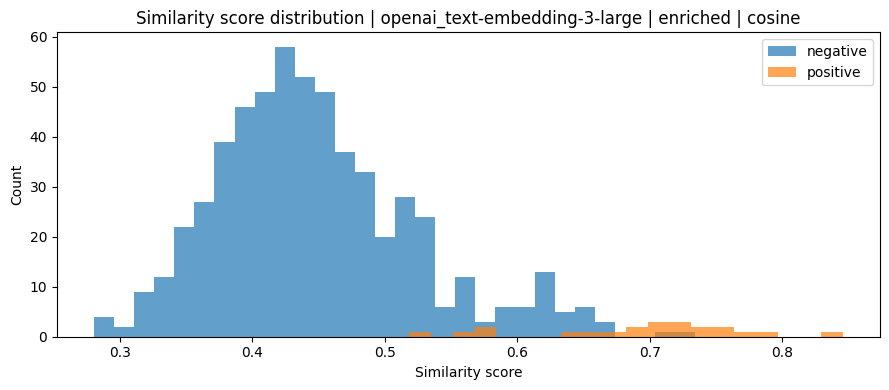

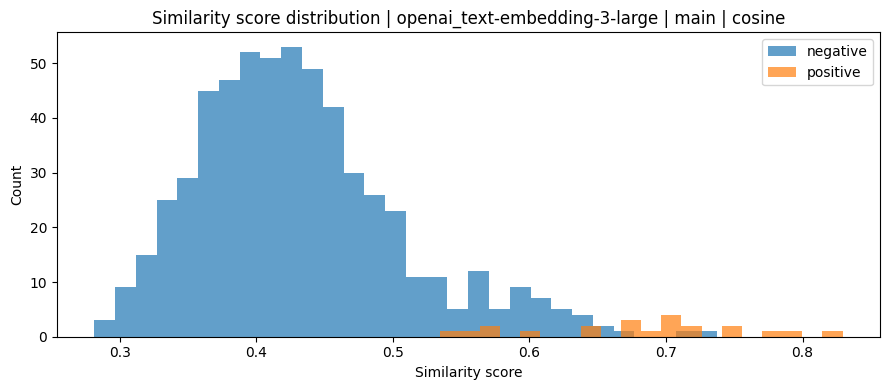

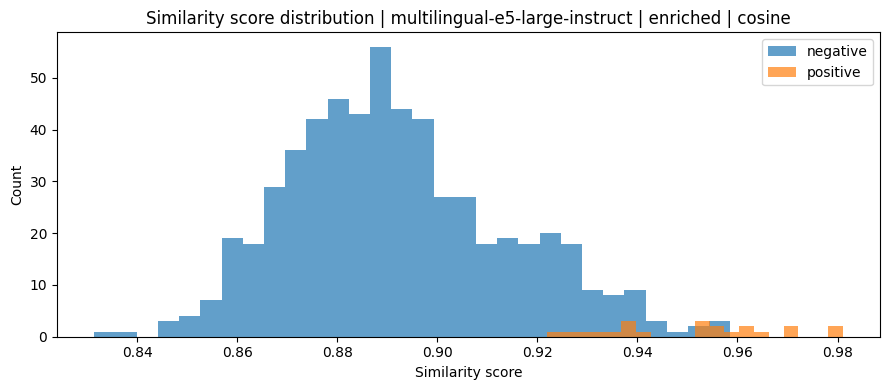

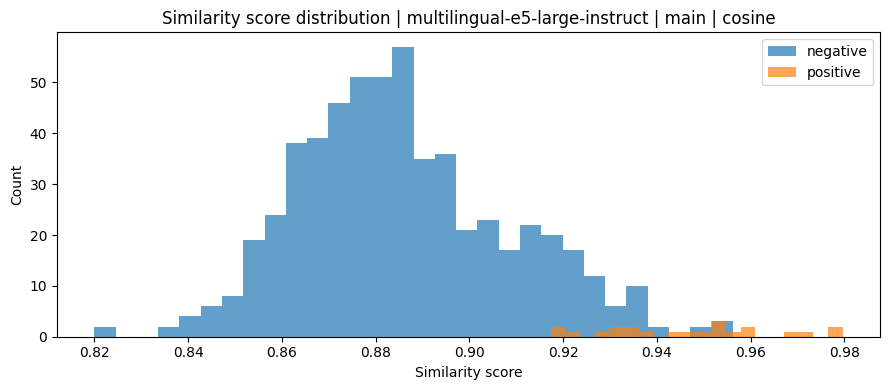

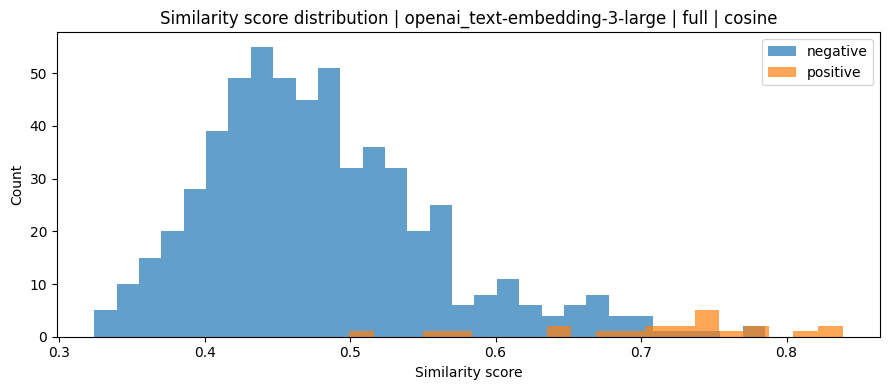

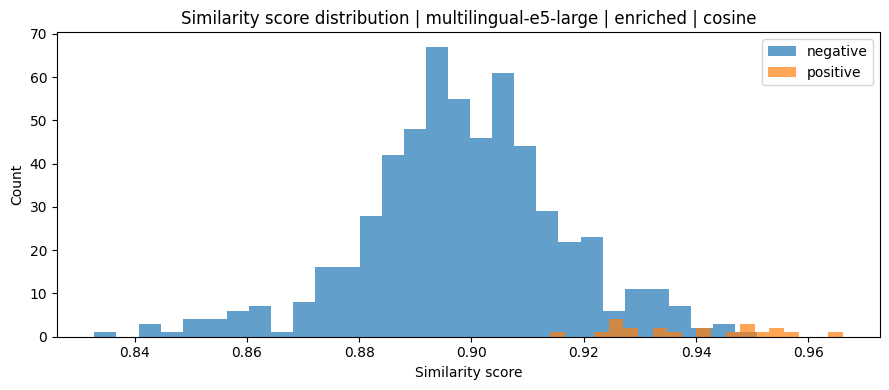

In [25]:
# Cell 24 - Plot score distributions for the top 6 configurations by Average Precision

for cfg in top_configs:
    model_name = cfg["model_name"]
    text_variant = cfg["text_variant"]
    similarity_metric = cfg["similarity_metric"]

    plot_df = dev_scores_df[
        (dev_scores_df["model_name"] == model_name) &
        (dev_scores_df["text_variant"] == text_variant) &
        (dev_scores_df["similarity_metric"] == similarity_metric)
    ].copy()

    pos_scores = plot_df.loc[plot_df["overlap_label_binary"] == 1, "similarity_score"]
    neg_scores = plot_df.loc[plot_df["overlap_label_binary"] == 0, "similarity_score"]

    plt.figure(figsize=(9, 4))
    plt.hist(neg_scores, bins=30, alpha=0.7, label="negative")
    plt.hist(pos_scores, bins=20, alpha=0.7, label="positive")
    plt.title(f"Similarity score distribution | {model_name} | {text_variant} | {similarity_metric}")
    plt.xlabel("Similarity score")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"hist_{slugify_name(model_name)}__{slugify_name(text_variant)}__{slugify_name(similarity_metric)}.png",
        dpi=150
    )
    plt.show()

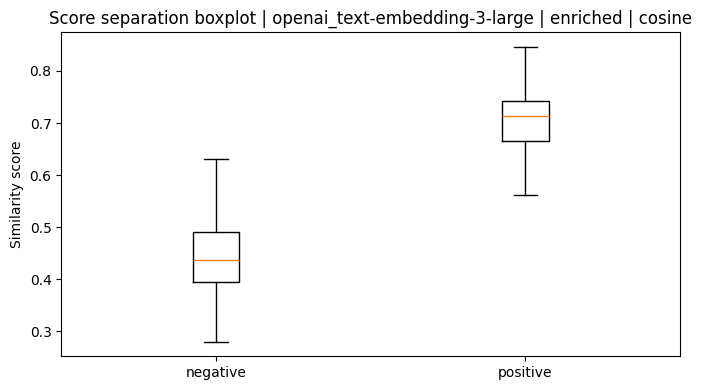

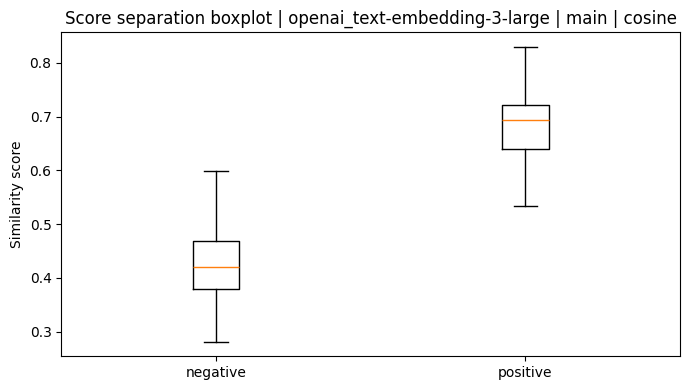

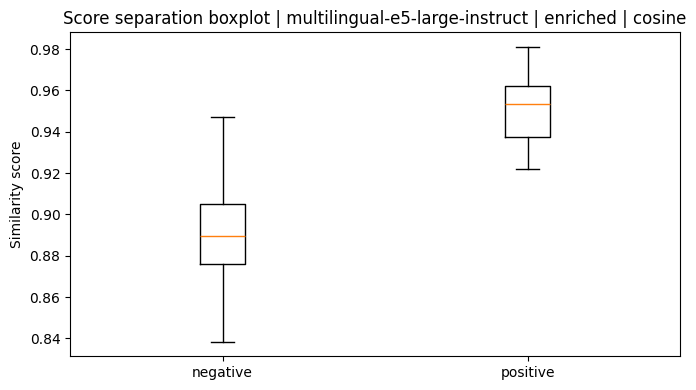

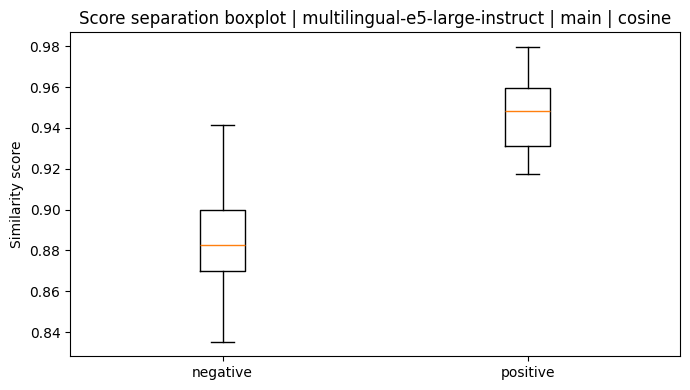

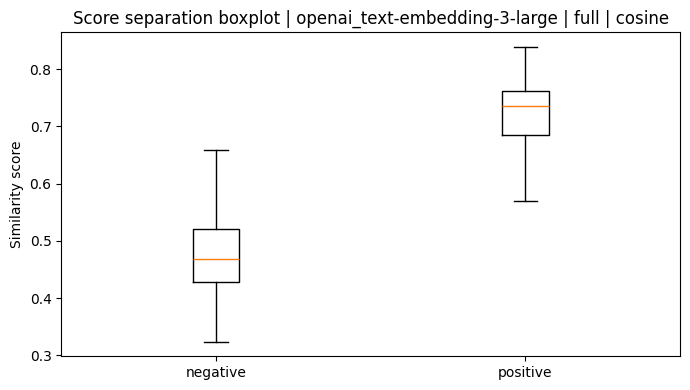

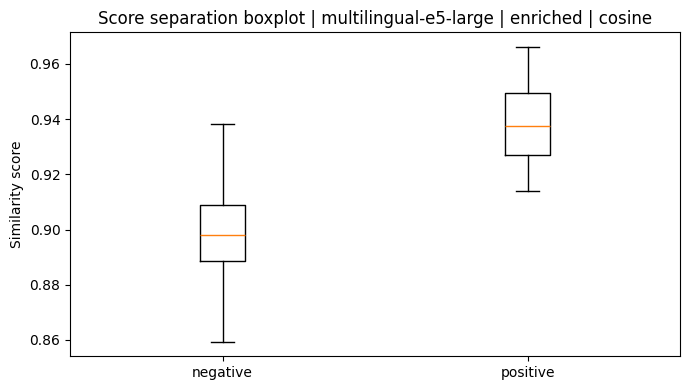

In [26]:
# Cell 25 - Boxplot comparison for the top 6 configurations

for cfg in top_configs:
    model_name = cfg["model_name"]
    text_variant = cfg["text_variant"]
    similarity_metric = cfg["similarity_metric"]

    plot_df = dev_scores_df[
        (dev_scores_df["model_name"] == model_name) &
        (dev_scores_df["text_variant"] == text_variant) &
        (dev_scores_df["similarity_metric"] == similarity_metric)
    ].copy()

    neg_scores = plot_df.loc[plot_df["overlap_label_binary"] == 0, "similarity_score"].tolist()
    pos_scores = plot_df.loc[plot_df["overlap_label_binary"] == 1, "similarity_score"].tolist()

    plt.figure(figsize=(7, 4))
    plt.boxplot([neg_scores, pos_scores], labels=["negative", "positive"], showfliers=False)
    plt.title(f"Score separation boxplot | {model_name} | {text_variant} | {similarity_metric}")
    plt.ylabel("Similarity score")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"boxplot_{slugify_name(model_name)}__{slugify_name(text_variant)}__{slugify_name(similarity_metric)}.png",
        dpi=150
    )
    plt.show()

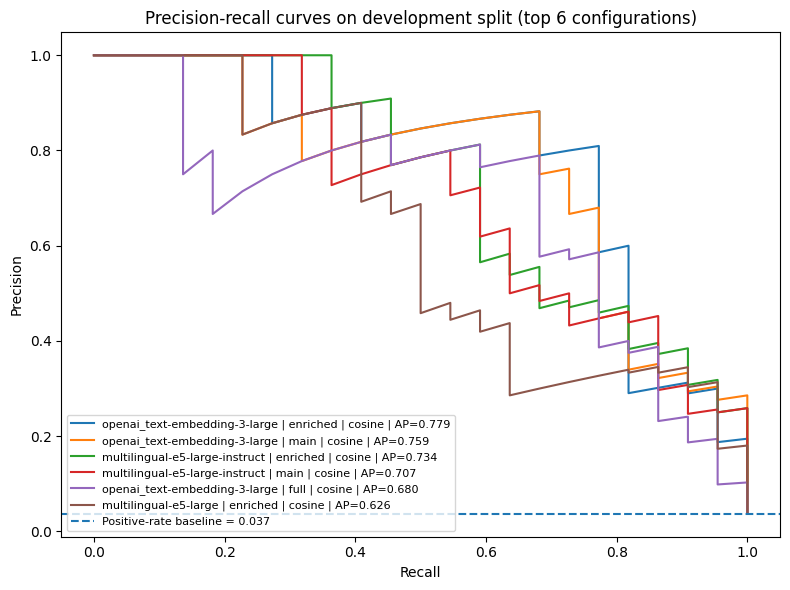

In [27]:
# Cell 26 - Precision-recall curves for the top 6 configurations

plt.figure(figsize=(8, 6))

for cfg in top_configs:
    model_name = cfg["model_name"]
    text_variant = cfg["text_variant"]
    similarity_metric = cfg["similarity_metric"]

    plot_df = dev_scores_df[
        (dev_scores_df["model_name"] == model_name) &
        (dev_scores_df["text_variant"] == text_variant) &
        (dev_scores_df["similarity_metric"] == similarity_metric)
    ].copy()

    y_true = plot_df["overlap_label_binary"].to_numpy()
    y_score = plot_df["similarity_score"].to_numpy()

    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    plt.plot(
        recall_vals,
        precision_vals,
        label=f"{model_name} | {text_variant} | {similarity_metric} | AP={ap:.3f}"
    )

baseline_precision = benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "dev", "overlap_label_binary"].mean()
plt.axhline(y=baseline_precision, linestyle="--", label=f"Positive-rate baseline = {baseline_precision:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curves on development split (top 6 configurations)")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "precision_recall_curves_dev_top6.png", dpi=150)
plt.show()

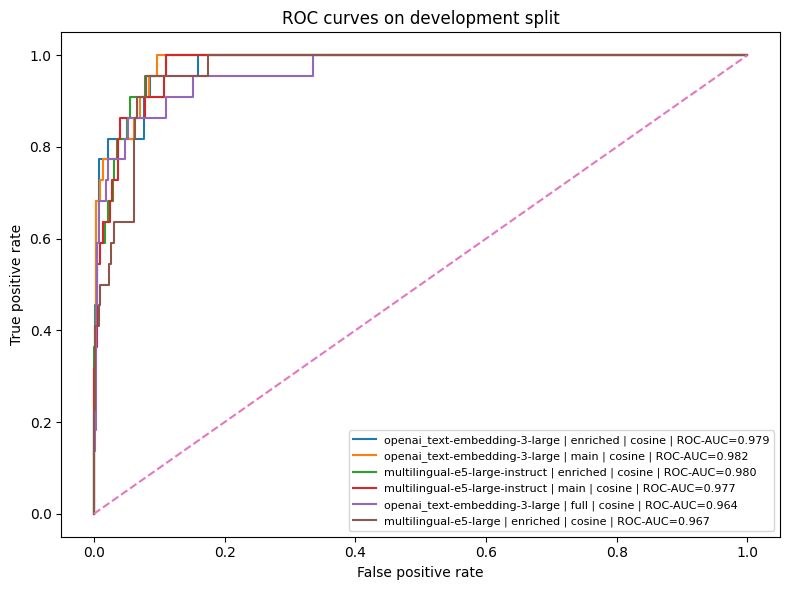

In [28]:
# Cell 27 - ROC curves for the top 6 configurations

plt.figure(figsize=(8, 6))

for cfg in top_configs:
    model_name = cfg["model_name"]
    text_variant = cfg["text_variant"]
    similarity_metric = cfg["similarity_metric"]

    plot_df = dev_scores_df[
        (dev_scores_df["model_name"] == model_name) &
        (dev_scores_df["text_variant"] == text_variant) &
        (dev_scores_df["similarity_metric"] == similarity_metric)
    ].copy()

    y_true = plot_df["overlap_label_binary"].to_numpy()
    y_score = plot_df["similarity_score"].to_numpy()

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} | {text_variant} | {similarity_metric} | ROC-AUC={roc_auc:.3f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves on development split")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_curves_dev_top6.png", dpi=150)
plt.show()

### Inspect top-ranked development pairs and hard false positives

A ranking benchmark should not be judged only by aggregate metrics.

This notebook inspects:
- highest-scoring development pairs overall
- highest-scoring negative pairs (hard false positives)

These cases help reveal where semantic similarity overgeneralizes.

In [29]:
# Cell 28 - Save and display top-ranked development pairs for each configuration

top_pair_rows = []

for (model_name, text_variant, similarity_metric), group_df in dev_scores_df.groupby(
    ["model_name", "text_variant", "similarity_metric"]
):
    ranked_df = group_df.sort_values("similarity_score", ascending=False).head(15).copy()
    ranked_df["rank_within_config"] = range(1, len(ranked_df) + 1)
    top_pair_rows.append(ranked_df)

top_ranked_dev_pairs_df = pd.concat(top_pair_rows, ignore_index=True)
top_ranked_dev_pairs_df.to_csv(TOP_PAIRS_CSV_PATH, index=False, encoding="utf-8")

print("Saved top-ranked dev pairs to:", TOP_PAIRS_CSV_PATH)

display(
    top_ranked_dev_pairs_df[[
        "model_name",
        "text_variant",
        "similarity_metric",
        "rank_within_config",
        "pair_id",
        "course_name_1",
        "course_name_2",
        "overlap_label_binary",
        "similarity_score",
        "review_notes",
    ]].head(30)
)

Saved top-ranked dev pairs to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark\top_ranked_dev_pairs_by_config.csv


,model_name,text_variant,similarity_metric,rank_within_config,pair_id,course_name_1,course_name_2,overlap_label_binary,similarity_score,review_notes
0,bge-m3,enriched,cosine,1,TT00CD83__TT00DB42,Data Structures and Algorithms,Data Structures and Algorithms,1,0.885749,"Same course at two institutions: lists, stacks, queues, trees, sorting, search algorithms, algorithm analysis."
1,bge-m3,enriched,cosine,2,TT00CD94__TT00DS75,Mobile Application Development,Mobile Application Development,1,0.857657,Same course at two institutions: mobile app design and implementation using modern frameworks.
2,bge-m3,enriched,cosine,3,TT00CD87__TT00CE11,Information Security Technologies,Data Security Controls,1,0.845275,Both cover technical information security controls and practical system/data protection methods.
3,bge-m3,enriched,cosine,4,TT00CD93__TT00CD94,Android Application Development,Mobile Application Development,1,0.840995,Both cover mobile app design and implementation with substantial shared mobile development content.
4,bge-m3,enriched,cosine,5,TE00CS89__TT00CD81,Databases,Databases,1,0.833601,"Same course at two institutions: SQL, database design, DBMS, conceptual modeling."
5,bge-m3,enriched,cosine,6,TT00CD87__TT00CD88,Information Security Technologies,Hardening,1,0.826106,Both focus on technical protection measures and hardening-oriented security practices.
6,bge-m3,enriched,cosine,7,TT00CD86__TT00CD87,Cyber Security,Information Security Technologies,1,0.822235,"Both cover core cyber/information security concepts, protection methods, and technical security practices."
7,bge-m3,enriched,cosine,8,TT00CD86__TT00CE08,Cyber Security,Basics of Cyber Security Exercises,0,0.821676,
8,bge-m3,enriched,cosine,9,TT00CD91__TT00DS61,Object Oriented Programming,Object-Oriented Programming with Python,1,0.817880,"Both cover classes, objects, encapsulation, inheritance, polymorphism, UML - same OOP content."
9,bge-m3,enriched,cosine,10,TT00CD85__TT00DS73,Backend Programming,Front-End Development,0,0.816111,


In [30]:
# Cell 29 - Hard false positives: highest-scoring negative pairs for each configuration

hard_false_positive_rows = []

for (model_name, text_variant, similarity_metric), group_df in dev_scores_df.groupby(
    ["model_name", "text_variant", "similarity_metric"]
):
    negatives_df = group_df[group_df["overlap_label_binary"] == 0].copy()
    hardest_df = negatives_df.sort_values("similarity_score", ascending=False).head(5).copy()
    hardest_df["hard_false_positive_rank"] = range(1, len(hardest_df) + 1)
    hard_false_positive_rows.append(hardest_df)

hard_false_positives_df = pd.concat(hard_false_positive_rows, ignore_index=True)
hard_false_positives_df.to_csv(HARD_FALSE_POSITIVES_CSV_PATH, index=False, encoding="utf-8")

print("Saved hard false positives to:", HARD_FALSE_POSITIVES_CSV_PATH)

display(
    hard_false_positives_df[[
        "model_name",
        "text_variant",
        "similarity_metric",
        "hard_false_positive_rank",
        "pair_id",
        "course_name_1",
        "course_name_2",
        "similarity_score",
        "review_notes",
    ]].head(30)
)

Saved hard false positives to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark\hard_false_positives_dev_top5_by_config.csv


,model_name,text_variant,similarity_metric,hard_false_positive_rank,pair_id,course_name_1,course_name_2,similarity_score,review_notes
0,bge-m3,enriched,cosine,1,TT00CD86__TT00CE08,Cyber Security,Basics of Cyber Security Exercises,0.821676,
1,bge-m3,enriched,cosine,2,TT00CD85__TT00DS73,Backend Programming,Front-End Development,0.816111,
2,bge-m3,enriched,cosine,3,TT00CD78__TT00CD85,Frontend Programming,Backend Programming,0.794198,
3,bge-m3,enriched,cosine,4,TT00CD86__TT00CE07,Cyber Security,Cyber Security Management,0.781913,
4,bge-m3,enriched,cosine,5,TT00DS73__TT00DS75,Front-End Development,Mobile Application Development,0.780564,
5,bge-m3,enriched,dot,1,TT00CD86__TT00CE08,Cyber Security,Basics of Cyber Security Exercises,0.821676,
6,bge-m3,enriched,dot,2,TT00CD85__TT00DS73,Backend Programming,Front-End Development,0.816111,
7,bge-m3,enriched,dot,3,TT00CD78__TT00CD85,Frontend Programming,Backend Programming,0.794198,
8,bge-m3,enriched,dot,4,TT00CD86__TT00CE07,Cyber Security,Cyber Security Management,0.781913,
9,bge-m3,enriched,dot,5,TT00DS73__TT00DS75,Front-End Development,Mobile Application Development,0.780564,


### Select shortlist candidates for Notebook 04

Notebook 04 should focus on a manageable set of strong candidates.

This shortlist keeps:
- strong dense candidates
- at least one `main`-variant comparison
- both lexical baselines
- avoids redundant cosine/dot duplicates when they are empirically identical for ranking

In [31]:
# Cell 30 - Build shortlist for Notebook 04 with near-tie handling

shortlist_source_df = benchmark_summary_dev_df.copy()
shortlist_source_df["metric_preference_rank"] = np.where(
    shortlist_source_df["similarity_metric"] == "cosine", 0, 1
)

AP_TOLERANCE = 0.002
ROC_AUC_TOLERANCE = 0.002
SPEARMAN_TOLERANCE = 0.002

def choose_preferred_metric(group_df):
    group_df = group_df.copy()

    available_metrics = set(group_df["similarity_metric"].tolist())

    if not {"cosine", "dot"}.issubset(available_metrics):
        return group_df.sort_values(
            ["average_precision", "roc_auc", "spearman_r", "metric_preference_rank"],
            ascending=[False, False, False, True]
        ).head(1)

    cosine_row = group_df[group_df["similarity_metric"] == "cosine"].iloc[0]
    dot_row = group_df[group_df["similarity_metric"] == "dot"].iloc[0]

    ap_diff = abs(cosine_row["average_precision"] - dot_row["average_precision"])
    roc_diff = abs(cosine_row["roc_auc"] - dot_row["roc_auc"])
    spearman_diff = abs(cosine_row["spearman_r"] - dot_row["spearman_r"])

    effectively_equivalent = (
        ap_diff <= AP_TOLERANCE
        and roc_diff <= ROC_AUC_TOLERANCE
        and spearman_diff <= SPEARMAN_TOLERANCE
    )

    if effectively_equivalent:
        return group_df[group_df["similarity_metric"] == "cosine"].head(1)

    return group_df.sort_values(
        ["average_precision", "roc_auc", "spearman_r", "metric_preference_rank"],
        ascending=[False, False, False, True]
    ).head(1)

# First collapse cosine-vs-dot redundancy within each model+variant
collapsed_rows = []
for (model_name, text_variant), group_df in shortlist_source_df.groupby(["model_name", "text_variant"]):
    collapsed_rows.append(choose_preferred_metric(group_df))

collapsed_shortlist_source_df = pd.concat(collapsed_rows, ignore_index=True)

# Then choose the best variant per model
best_per_model_df = (
    collapsed_shortlist_source_df
    .sort_values(
        ["model_name", "average_precision", "roc_auc", "spearman_r"],
        ascending=[True, False, False, False]
    )
    .groupby("model_name", as_index=False)
    .head(1)
    .copy()
)

best_main_df = collapsed_shortlist_source_df[
    collapsed_shortlist_source_df["text_variant"] == "main"
].copy()

best_main_row = None
if not best_main_df.empty:
    best_main_row = best_main_df.sort_values(
        ["average_precision", "roc_auc", "spearman_r"],
        ascending=[False, False, False]
    ).head(1)

shortlist_df = best_per_model_df.copy()

if best_main_row is not None:
    candidate_model = best_main_row.iloc[0]["model_name"]
    candidate_variant = best_main_row.iloc[0]["text_variant"]
    candidate_metric = best_main_row.iloc[0]["similarity_metric"]

    already_present = (
        (shortlist_df["model_name"] == candidate_model) &
        (shortlist_df["text_variant"] == candidate_variant) &
        (shortlist_df["similarity_metric"] == candidate_metric)
    ).any()

    if not already_present:
        shortlist_df = pd.concat([shortlist_df, best_main_row], ignore_index=True)

# Always keep TF-IDF cosine baseline if available
tfidf_cosine_df = collapsed_shortlist_source_df[
    (collapsed_shortlist_source_df["model_name"] == "tfidf") &
    (collapsed_shortlist_source_df["similarity_metric"] == "cosine")
].sort_values(["average_precision", "roc_auc", "spearman_r"], ascending=[False, False, False]).head(1)

if not tfidf_cosine_df.empty:
    tfidf_row = tfidf_cosine_df.iloc[0]
    tfidf_already_present = (
        (shortlist_df["model_name"] == tfidf_row["model_name"]) &
        (shortlist_df["text_variant"] == tfidf_row["text_variant"]) &
        (shortlist_df["similarity_metric"] == tfidf_row["similarity_metric"])
    ).any()

    if not tfidf_already_present:
        shortlist_df = pd.concat([shortlist_df, tfidf_cosine_df], ignore_index=True)

# Always keep BM25 if available
bm25_df = collapsed_shortlist_source_df[
    collapsed_shortlist_source_df["model_name"] == "bm25"
].sort_values(["average_precision", "roc_auc", "spearman_r"], ascending=[False, False, False]).head(1)

if not bm25_df.empty:
    bm25_row = bm25_df.iloc[0]
    bm25_already_present = (
        (shortlist_df["model_name"] == bm25_row["model_name"]) &
        (shortlist_df["text_variant"] == bm25_row["text_variant"]) &
        (shortlist_df["similarity_metric"] == bm25_row["similarity_metric"])
    ).any()

    if not bm25_already_present:
        shortlist_df = pd.concat([shortlist_df, bm25_df], ignore_index=True)

shortlist_df = shortlist_df.sort_values(
    ["average_precision", "roc_auc", "spearman_r"],
    ascending=[False, False, False]
).reset_index(drop=True)

SHORTLIST_LIMIT = 8
shortlist_df = shortlist_df.head(SHORTLIST_LIMIT).copy()
shortlist_df["shortlist_rank"] = range(1, len(shortlist_df) + 1)

shortlist_df.to_csv(SHORTLIST_CSV_PATH, index=False, encoding="utf-8")

print("Saved shortlist to:", SHORTLIST_CSV_PATH)
display(shortlist_df)

Saved shortlist to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark\shortlist_for_notebook_04.csv


,model_name,text_variant,similarity_metric,pair_count_dev,positive_count_dev,negative_count_dev,positive_rate_dev,similarity_mean_positive,similarity_mean_negative,similarity_mean_gap,similarity_median_positive,similarity_median_negative,similarity_median_gap,average_precision,ap_lift_vs_prevalence,roc_auc,spearman_r,metric_preference_rank,shortlist_rank
0,openai_text-embedding-3-large,enriched,cosine,595,22,573,0.036975,0.693646,0.448394,0.245252,0.712736,0.437120,0.275617,0.779220,21.074359,0.979137,0.313201,0,1
1,openai_text-embedding-3-large,main,cosine,595,22,573,0.036975,0.680026,0.430930,0.249096,0.693052,0.420355,0.272697,0.758621,20.517253,0.981755,0.314912,0,2
2,multilingual-e5-large-instruct,enriched,cosine,595,22,573,0.036975,0.951126,0.891910,0.059215,0.953658,0.889709,0.063949,0.733995,19.851235,0.979613,0.313512,0,3
3,multilingual-e5-large,enriched,cosine,595,22,573,0.036975,0.938824,0.898484,0.040339,0.937541,0.898181,0.039360,0.625860,16.926665,0.966762,0.305111,0,4
4,bge-m3,enriched,cosine,595,22,573,0.036975,0.766341,0.624136,0.142205,0.774719,0.615643,0.159076,0.619737,16.761063,0.939473,0.287273,0,5
5,multilingual-e5-base,main,cosine,595,22,573,0.036975,0.930973,0.891037,0.039936,0.932340,0.890958,0.041382,0.589277,15.937269,0.961606,0.301741,0,6
6,tfidf,main,cosine,595,22,573,0.036975,0.259507,0.118893,0.140614,0.236603,0.112542,0.124061,0.452223,12.230564,0.874663,0.244908,0,7
7,bm25,main,bm25,595,22,573,0.036975,183.429635,68.725593,114.704042,166.267349,60.304100,105.963249,0.382624,10.348247,0.935190,0.284473,1,8


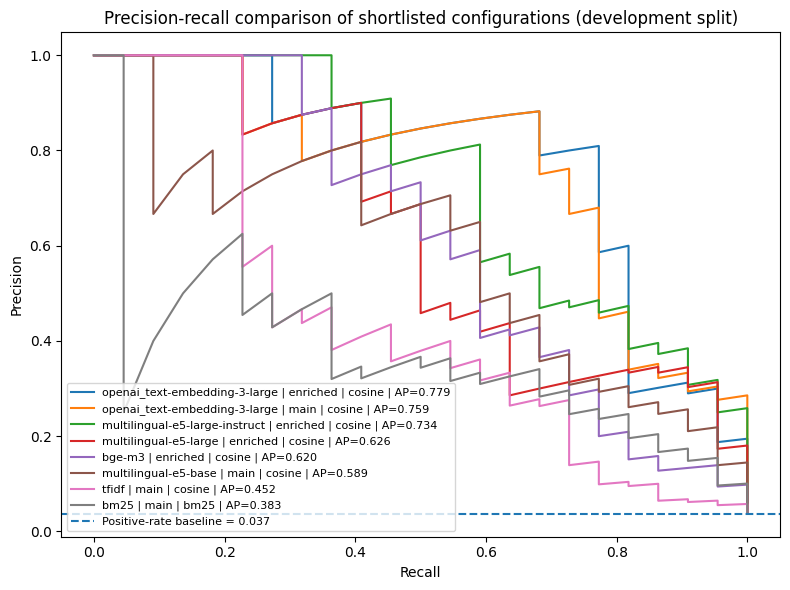

Saved shortlist PR comparison plot to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\figures\benchmark\precision_recall_curves_dev_shortlist.png


In [32]:
# Cell 31 - Final comparison plot for shortlisted configurations

comparison_df = shortlist_df[["model_name", "text_variant", "similarity_metric"]].drop_duplicates().copy()

plt.figure(figsize=(8, 6))

for _, row in comparison_df.iterrows():
    model_name = row["model_name"]
    text_variant = row["text_variant"]
    similarity_metric = row["similarity_metric"]

    plot_df = dev_scores_df[
        (dev_scores_df["model_name"] == model_name) &
        (dev_scores_df["text_variant"] == text_variant) &
        (dev_scores_df["similarity_metric"] == similarity_metric)
    ].copy()

    y_true = plot_df["overlap_label_binary"].to_numpy()
    y_score = plot_df["similarity_score"].to_numpy()

    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    plt.plot(
        recall_vals,
        precision_vals,
        label=f"{model_name} | {text_variant} | {similarity_metric} | AP={ap:.3f}"
    )

baseline_precision = benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "dev", "overlap_label_binary"].mean()
plt.axhline(y=baseline_precision, linestyle="--", label=f"Positive-rate baseline = {baseline_precision:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall comparison of shortlisted configurations (development split)")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()

shortlist_pr_plot_path = FIGURES_DIR / "precision_recall_curves_dev_shortlist.png"
plt.savefig(shortlist_pr_plot_path, dpi=150)
plt.show()

print("Saved shortlist PR comparison plot to:", shortlist_pr_plot_path)

### Interpretation guide for thesis writing

When writing up Notebook 03 in the thesis, the main interpretation should focus on:

- whether semantic models outperform the lexical baselines
- whether `main`, `enriched`, or `full` produces the clearest separation
- whether cosine and dot produce meaningfully different results
- whether the best method produces practically useful score separation
- whether hard false positives reveal consistent semantic overgeneralization patterns

Important:
- high ROC-AUC alone is not enough
- raw accuracy is not meaningful under strong class imbalance
- final threshold tuning belongs to Notebook 04
- Average Precision and AP lift above prevalence are the most useful ranking summaries here
- similarity-gap columns are practically useful because very small positive-vs-negative score gaps can make threshold selection fragile
- full-variant results for long-context models should not be directly compared with missing full-variant E5 runs as if they came from identical input conditions

In [33]:
# Cell 32 - Winner summary for Notebook 04 with near-tie handling

winner_source_df = benchmark_summary_dev_df.copy()
winner_source_df["metric_preference_rank"] = np.where(
    winner_source_df["similarity_metric"] == "cosine", 0, 1
)

AP_TOLERANCE = 0.002
ROC_AUC_TOLERANCE = 0.002
SPEARMAN_TOLERANCE = 0.002

def choose_preferred_metric(group_df):
    group_df = group_df.copy()

    available_metrics = set(group_df["similarity_metric"].tolist())

    if not {"cosine", "dot"}.issubset(available_metrics):
        return group_df.sort_values(
            ["average_precision", "roc_auc", "spearman_r", "metric_preference_rank"],
            ascending=[False, False, False, True]
        ).head(1)

    cosine_row = group_df[group_df["similarity_metric"] == "cosine"].iloc[0]
    dot_row = group_df[group_df["similarity_metric"] == "dot"].iloc[0]

    ap_diff = abs(cosine_row["average_precision"] - dot_row["average_precision"])
    roc_diff = abs(cosine_row["roc_auc"] - dot_row["roc_auc"])
    spearman_diff = abs(cosine_row["spearman_r"] - dot_row["spearman_r"])

    effectively_equivalent = (
        ap_diff <= AP_TOLERANCE
        and roc_diff <= ROC_AUC_TOLERANCE
        and spearman_diff <= SPEARMAN_TOLERANCE
    )

    if effectively_equivalent:
        return group_df[group_df["similarity_metric"] == "cosine"].head(1)

    return group_df.sort_values(
        ["average_precision", "roc_auc", "spearman_r", "metric_preference_rank"],
        ascending=[False, False, False, True]
    ).head(1)

winner_rows = []
for (model_name, text_variant), group_df in winner_source_df.groupby(["model_name", "text_variant"]):
    winner_rows.append(choose_preferred_metric(group_df))

winner_candidates_df = pd.concat(winner_rows, ignore_index=True)

best_row = winner_candidates_df.sort_values(
    ["average_precision", "roc_auc", "spearman_r"],
    ascending=[False, False, False]
).iloc[0]

dev_pair_count = int(benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "dev"].shape[0])
dev_positive_count = int(benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "dev", "overlap_label_binary"].sum())
test_pair_count = int(benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "test"].shape[0])
test_positive_count = int(benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "test", "overlap_label_binary"].sum())

print("Best development configuration overall:")
print(f"  Model: {best_row['model_name']}")
print(f"  Text variant: {best_row['text_variant']}")
print(f"  Similarity metric: {best_row['similarity_metric']}")
print(f"  Average Precision: {best_row['average_precision']:.4f}")
print(f"  AP lift vs prevalence: {best_row['ap_lift_vs_prevalence']:.2f}x")
print(f"  ROC-AUC: {best_row['roc_auc']:.4f}")
print(f"  Spearman r: {best_row['spearman_r']:.4f}")
print(f"  Mean similarity gap: {best_row['similarity_mean_gap']:.4f}")
print(f"  Median similarity gap: {best_row['similarity_median_gap']:.4f}")
print()

print("Evaluation context:")
print(f"  Dev pairs: {dev_pair_count}")
print(f"  Dev positives: {dev_positive_count}")
print(f"  Test pairs: {test_pair_count}")
print(f"  Test positives: {test_positive_count}")
print()

print("Interpretation:")
print(
    "For dense models in this dataset, cosine and dot are often identical or near-identical in ranking quality. "
    "When the differences are negligible across Average Precision, ROC-AUC, and Spearman correlation, cosine is preferred for interpretability. "
    "If the difference is clearly meaningful, the empirically stronger metric is retained."
)

Best development configuration overall:
  Model: openai_text-embedding-3-large
  Text variant: enriched
  Similarity metric: cosine
  Average Precision: 0.7792
  AP lift vs prevalence: 21.07x
  ROC-AUC: 0.9791
  Spearman r: 0.3132
  Mean similarity gap: 0.2453
  Median similarity gap: 0.2756

Evaluation context:
  Dev pairs: 595
  Dev positives: 22
  Test pairs: 105
  Test positives: 8

Interpretation:
For dense models in this dataset, cosine and dot are often identical or near-identical in ranking quality. When the differences are negligible across Average Precision, ROC-AUC, and Spearman correlation, cosine is preferred for interpretability. If the difference is clearly meaningful, the empirically stronger metric is retained.


## Final note

Notebook 03 benchmarks **score quality** across lexical and dense embedding methods using a **course-level** development/test split.

### What this notebook does well
- aligns evaluation more closely with held-out generalization than a pair-level split
- compares multiple text variants instead of assuming one representation is best
- compares both cosine similarity and dot product where appropriate
- includes two lexical baselines for context
- uses a context-aware variant assignment so short-context models are not unfairly evaluated on the longest representation
- separates model screening from later threshold selection
- saves reusable benchmark artifacts for Notebook 04
- includes both quantitative ranking metrics and qualitative error inspection

### Why this design is appropriate
This thesis is not only about producing a similarity score. It is about understanding which representation, embedding model, and similarity metric produce scores that are most useful for overlap detection under realistic class imbalance. That is why Notebook 03 focuses on ranking quality, score separation, and error patterns rather than final threshold tuning.

### Important limitations
- The dataset is small and overlap pairs are rare.
- The course-level split is constructed using a constrained search to preserve a minimally usable number of positive pairs in both dev and test.
- Some labeled positive pairs are excluded from both development and test evaluation because mixed pairs are discarded.
- Even after improvement, the test split still contains only a small number of positive pairs, so Notebook 04 threshold metrics should be interpreted cautiously.
- Full-variant comparisons are available only for lexical baselines and long-context models, because the E5-family models would be unfairly penalized by severe truncation on that variant.
- If cosine and dot produce effectively identical rankings for dense models, that should be interpreted as an empirical property of the embedding norms in this dataset rather than as a benchmarking failure.

Notebook 04 will use the shortlisted configurations from this notebook to choose and evaluate operating thresholds more carefully.